# FDCA Part I — Walkthrough paso a paso

Este notebook desglosa **`part1.py`** del pipeline GERIS-PFC, ejecutando cada etapa de forma aislada y mostrando qué produce.

La estructura sigue las secciones ATBD 3.4.2.1 → 3.4.2.13:

| Sección | Qué hace |
|---------|----------|
| 3.4.2.1 | Albedo y brillo visible |
| 3.4.2.2 | Banda híbrida FPT + producto Reflectividad |
| 3.4.2.3 | Tests de nube y geometría |
| 3.4.2.4 | Test along-scan |
| 3.4.2.5 | Background estadístico |
| 3.4.2.6 | Umbrales contextuales |
| 3.4.2.7 | Identificación inicial de píxeles de fuego |
| 3.4.2.8 | Correcciones TPW + emisividad + solar |
| 3.4.2.9 | Tests post-corrección |
| 3.4.2.10 | Dozier sub-pixel + área |
| 3.4.2.11 | Last-chance fire test |
| 3.4.2.12 | FRP |
| 3.4.2.13 | Registro del candidato |



## 0. Setup: cargar repo del proyecto y archivos a utilizar


In [1]:
import os
import sys
import subprocess
from pathlib import Path

# Detectar si estamos en Google Colab
try:
    from google.colab import userdata
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

BRANCH = "testing-fdca-real"

if IN_COLAB:
    print("Ejecutando en Google Colab")

    GH_TOKEN = userdata.get("GITHUB_TOKEN")
    REPO_URL = f"https://{GH_TOKEN}@github.com/Vale23-23/GERIS-PFC.git"
    CLONE_DIR = "/content/GERIS-PFC"

    if not os.path.exists(CLONE_DIR):
        result = subprocess.run(
            [
                "git", "clone",
                "--branch", BRANCH,
                "--depth", "1",
                REPO_URL,
                CLONE_DIR
            ],
            capture_output=True,
            text=True
        )

        if result.returncode != 0:
            raise RuntimeError(result.stderr)

        print("Repo clonado OK")

    else:
        pull = subprocess.run(
            ["git", "-C", CLONE_DIR, "pull"],
            capture_output=True,
            text=True
        )
        print("Pull OK")

    PROJECT_ROOT = Path(CLONE_DIR) / "implementacion"

else:
    print("Ejecutando localmente (VS Code u otro IDE)")

    cwd = Path.cwd()
    if (cwd / "implementacion" / "fdca").exists():
        PROJECT_ROOT = cwd / "implementacion"
    elif (cwd / "fdca").exists():
        PROJECT_ROOT = cwd
    else:
        PROJECT_ROOT = cwd

print(f"PROJECT_ROOT = {PROJECT_ROOT}")

sys.path.insert(0, str(PROJECT_ROOT))

Ejecutando localmente (VS Code u otro IDE)
PROJECT_ROOT = /Users/valentinachagas/Documents/GitHub/GERIS-PFC/implementacion


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
%pip install python-dotenv


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [62]:
# ── Celda 2: bajar datos desde Hugging Face ───────────────────────────────
import os
TIMESTAMP = "20251117_1820"
try:
    from google.colab import userdata
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    HF_TOKEN = userdata.get("HF_TOKEN")
    DATA_ROOT = "/content/data"
else:
    from dotenv import load_dotenv

    env_candidates = [Path.cwd() / ".env", Path.cwd().parent / ".env"]
    for env_path in env_candidates:
        if env_path.exists():
            load_dotenv(env_path)
            break

    HF_TOKEN = os.getenv("HF_TOKEN")
    DATA_ROOT = Path.cwd() / "data"





In [63]:
from huggingface_hub import snapshot_download

HF_REPO_ID = "valentina2323/GERIS-Goes19-uruguay-fires"
MONTH = TIMESTAMP[4:6]
LOCAL_DATA = os.path.join(DATA_ROOT, TIMESTAMP)

os.makedirs(LOCAL_DATA, exist_ok=True)

snapshot_download(
    repo_id=HF_REPO_ID,
    repo_type="dataset",
    token=HF_TOKEN,
    allow_patterns=[
        f"uruguay/*/{TIMESTAMP}.npy",
        f"uruguay/*/{TIMESTAMP}_planck.json",
        f"uruguay/*/{TIMESTAMP}_dqf.npy",
        "uruguay/geometry.json",
        f"uruguay/camel_emissivity/*{MONTH}Month*.nc",
    ],
    local_dir=str(DATA_ROOT),
)

print(f"Datos en: {LOCAL_DATA}")

Fetching 13 files: 100%|██████████| 13/13 [00:05<00:00,  2.53it/s]

Datos en: /Users/valentinachagas/Documents/GitHub/GERIS-PFC/implementacion/data/20251117_1820


In [65]:
from pathlib import Path

print(list(Path(DATA_ROOT).glob("*")))

[PosixPath('/Users/valentinachagas/Documents/GitHub/GERIS-PFC/implementacion/data/20251126_1900'), PosixPath('/Users/valentinachagas/Documents/GitHub/GERIS-PFC/implementacion/data/uruguay'), PosixPath('/Users/valentinachagas/Documents/GitHub/GERIS-PFC/implementacion/data/20251117_1820'), PosixPath('/Users/valentinachagas/Documents/GitHub/GERIS-PFC/implementacion/data/.cache')]


## 1. Cargar datos de entrada (`FDCAInput`)

Usamos la misma escena de prueba del README: timestamp `20250926_1900`.

In [66]:
# ── Celda 3: imports y carga del input ───────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
from pathlib import Path
import json, warnings

# Módulos del proyecto
from fdca.fdca_adapter import load_fdca_input
from fdca.planck import planck_rad, planck_temp
from fdca.background import compute_background
from fdca.dozier import compute_dozier, compute_frp, compute_pixel_area
from fdca.part1 import (
    FireCandidate, _contextual_thresholds,
    _tpw_lut_indices, _solar_correction,
    run_part1,
)
from fdca.constants import *

warnings.filterwarnings('ignore')
print('Imports OK')

Imports OK


In [67]:
import sys
import numpy as np
sys.path.insert(0, str(PROJECT_ROOT))

from fdca.fdca_adapter import load_fdca_input

CONFIG_PATH = str(PROJECT_ROOT / "fdca" / "config.yaml")
DATASET_ROOT = str(DATA_ROOT)   # si la celda anterior definió DATA_ROOT

inp = load_fdca_input(
    timestamp=TIMESTAMP,
    region="uruguay",
    config_path=CONFIG_PATH,
    dataset_root=DATASET_ROOT,
    verbose=True
)

print(f"Grilla: {inp.bt7.shape}  |  BT7 [{np.nanmin(inp.bt7):.1f}, {np.nanmax(inp.bt7):.1f}] K")



  ABI-L1b-Rad-B07       : shape=(224, 303)  range=[0.14, 2.33]
  ABI-L1b-Rad-B14       : shape=(224, 303)  range=[28.32, 148.04]
  ABI-L1b-Rad-B13       : shape=(224, 303)  range=[24.06, 132.48]
  ABI-L1b-Rad-B15       : shape=(224, 303)  range=[33.66, 152.24]
  ABI-L1b-Rad-B02       : shape=(893, 1212)  range=[-1.26, 500.53]

  SZA range [°]         : 33.1 – 40.0
  LZA range [°]         : 31.3 – 40.1
  Píxeles diurnos       : 100%

  BT7 range [K]         : 259.2 – 324.1
  BT14 range [K]        : 225.2 – 316.1
  refl2 range           : 0.038 – 0.827
  Emisividad            : ⚠ placeholder — corré 'python pipeline.py download-camel --month 11 --region uruguay' en la branch de descarga
  TPW range [mm]        : 25.0 – 35.0  (estimación climatológica)

  ✓ FDCAInput construido — shape (224, 303)
Grilla: (224, 303)  |  BT7 [259.2, 324.1] K


In [68]:
import pandas as pd

# Ver los atributos principales del objeto
fields = {
    "campo": [],
    "tipo": [],
    "shape": [],
}

for name in dir(inp):
    if name.startswith("_"):
        continue
    value = getattr(inp, name)
    if hasattr(value, "shape"):
        fields["campo"].append(name)
        fields["tipo"].append(type(value).__name__)
        fields["shape"].append(value.shape)
    elif hasattr(value, "__len__") and not isinstance(value, (str, bytes)):
        try:
            fields["campo"].append(name)
            fields["tipo"].append(type(value).__name__)
            fields["shape"].append(len(value))
        except Exception:
            pass

pd.DataFrame(fields).head(50)

,campo,tipo,shape
0,azimuth,ndarray,"(224, 303)"
1,bt13,ndarray,"(224, 303)"
2,bt14,ndarray,"(224, 303)"
3,bt15,ndarray,"(224, 303)"
4,bt7,ndarray,"(224, 303)"
5,coeffs13,dict,4
6,coeffs14,dict,4
7,coeffs15,dict,4
8,coeffs7,dict,4
9,desert_mask,ndarray,"(224, 303)"


In [69]:
# Ejemplo: ver un resumen de una variable
pd.Series(inp.sza[0, :10]).to_frame(name="BT7 primer fila")

,BT7 primer fila
0,33.103420
1,33.122395
2,33.141350
3,33.160328
4,33.179302
5,33.198277
6,33.217243
7,33.236214
8,33.255211
9,33.274181


---
## ATBD 3.4.2.1: Albedo y brillo visible

El albedo normalizado por SZA se calcula como:
$$\text{albedo}_{ij} = \frac{\text{refl2}_{ij}}{\cos(\text{SZA}_{ij})}$$

Solo aplica de día (`SZA ≤ MAX_SZA_DAYLIGHT = 85°`).
Esto corrige la reflectancia cruda por el ángulo de iluminación solar: a mayor SZA, el sol ilumina más oblicuamente y la misma superficie parece más brillante en reflectancia cruda. Al dividir por cos(SZA) se obtiene una medida más "física" de la reflectividad real.

Se maneja en una escala adimensional que va de 0.0 a 1.5 (donde valores mayores a 1.0 surgen técnicamente por la geometría de la reflexión y el ruido).  


In [70]:
from fdca.part1 import calculate_albedo

L, W = inp.bt7.shape

albedo, vis_brightness, is_day, sza_cos = calculate_albedo(L, W, inp.sza, inp.refl2)

print(f'Píxeles diurnos : {is_day.sum():,} / {L*W:,} ({100*is_day.mean():.1f}%)')
print(f'Albedo válido   : {np.isfinite(albedo).sum():,} píxeles')
print(f'Albedo rango    : [{np.nanmin(albedo):.4f}, {np.nanmax(albedo):.4f}]')

Píxeles diurnos : 67,872 / 67,872 (100.0%)
Albedo válido   : 67,872 píxeles
Albedo rango    : [0.0467, 1.0459]


In [71]:
albedo.mean()

0.14832008

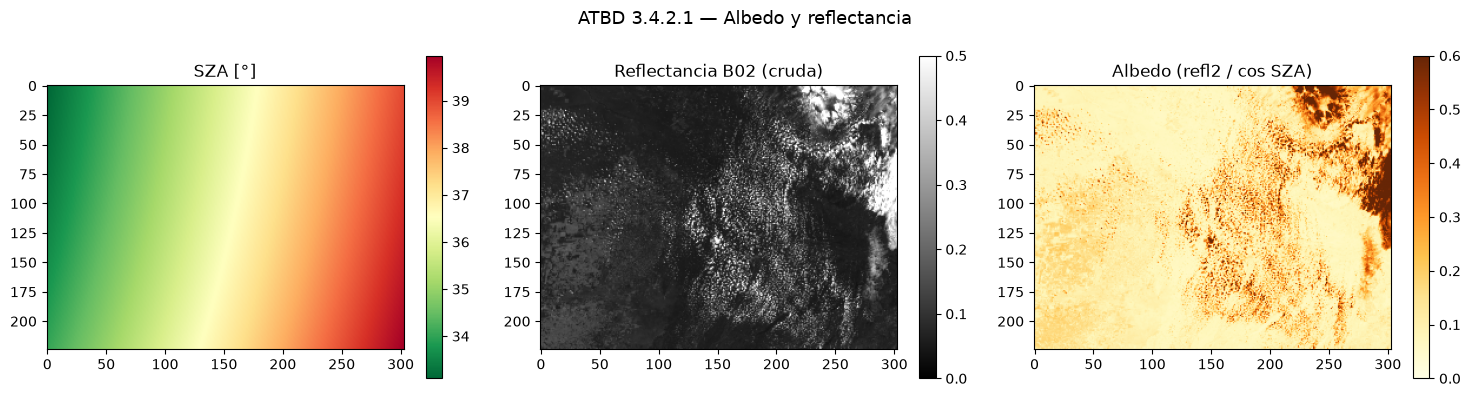

In [72]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im0 = axes[0].imshow(inp.sza, cmap='RdYlGn_r', origin='upper')
plt.colorbar(im0, ax=axes[0])
axes[0].set_title('SZA [°]')

if inp.refl2 is not None:
    im1 = axes[1].imshow(inp.refl2, cmap='gray', origin='upper', vmin=0, vmax=0.5)
    plt.colorbar(im1, ax=axes[1])
    axes[1].set_title('Reflectancia B02 (cruda)')
else:
    axes[1].text(0.5, 0.5, 'B02 no disponible', ha='center', va='center', transform=axes[1].transAxes)

im2 = axes[2].imshow(albedo, cmap='YlOrBr', origin='upper', vmin=0, vmax=0.6)
plt.colorbar(im2, ax=axes[2])
axes[2].set_title('Albedo (refl2 / cos SZA)')

plt.suptitle('ATBD 3.4.2.1 — Albedo y reflectancia', fontsize=13)
plt.tight_layout()
plt.show()

El sol está más alto en el cielo hacia la izquierda de la imagen (oeste) y más bajo (más inclinado, proyectando más sombras) hacia la derecha (este). Esta inclinación causa que, a igual tipo de suelo, la derecha de la imagen reciba naturalmente menos iluminación solar directa que la izquierda.
El albedo es el factor de reflectancia corregido y normalizado que utiliza el FDCA para sus árboles de decisión diurnos. Al dividir la reflectancia cruda por el coseno del ángulo solar (SZA) de cada píxel, eliminás el efecto de iluminación oblicua causado por la curvatura de la Tierra y la hora del día. Los valores dominantes están en el rango de 0.1 a 0.25 (tonos amarillos y crema suaves), que es el rango exacto de validación física para pastizales, campos de cultivo y montes limpios en el Cono Sur. Hacia el extremo inferior izquierdo (suroeste), se aprecian algunas estructuras con un albedo levemente más alto (tonos naranja/marrón de 0.25 a 0.35) que podrían ser suelos más descubiertos, texturas de biomas mixtos o nubes muy delgadas/humo que empiezan a dispersar luz visible sin llegar al umbral crítico de nube opaca (>0.38).  

---
## ATBD 3.4.2.2: Banda híbrida FPT + producto Reflectividad

Si la temperatura del plano focal (`FPT > FPT_THRESHOLD`), el detector de B07 está tan caliente que contamina las mediciones, y en ese caso se substituye B14 por B13, donde reduce la diferencia con B07. Luego se calcula el **producto Reflectividad** para todos los píxeles:

$$\text{Refl}_{ij} = \text{rad7}_{ij} - B_{\text{Planck}}(7,\, \text{BT14}_{ij})$$

In [73]:
# Leer FPT del input 
FPT = inp.FPT
AFFECTED_PIXELS = FPT > FPT_THRESHOLD # Si FPT supera el umbral, entonces hay pixeles afectados

print(f'FPT= {FPT:.2f}   |   FPT_THRESHOLD = {FPT_THRESHOLD} K   |   posible uso híbrido = {AFFECTED_PIXELS}')

if AFFECTED_PIXELS == True :
    use_hybrid = True
else:
    use_hybrid = False #es como overkill, podriamos ver que sea con el 10% afectados

if use_hybrid and inp.bt13 is not None:
    from fdca.planck import planck_rad_from_coeffs
    rad13_in_ch7 = planck_rad_from_coeffs(inp.bt13, **inp.coeffs7)
    rad14_in_ch7 = planck_rad_from_coeffs(inp.bt14, **inp.coeffs7)
    refl_7_14 = inp.rad7 - rad14_in_ch7
    refl_7_13 = inp.rad7 - rad13_in_ch7

    use_ch13  = np.abs(refl_7_13) < np.abs(refl_7_14)
    bt14_eff  = np.where(use_ch13, inp.bt13, inp.bt14)
    rad14_eff = np.where(use_ch13, inp.rad13, inp.rad14)
    print(f'Píxeles donde B13 reemplaza B14: {use_ch13.sum():,}')
else:
    bt14_eff  = inp.bt14
    rad14_eff = inp.rad14
    print('Usando B14 estándar (sin banda híbrida)')

# Producto Reflectividad (ATBD 3.4.2.2)
# IMPORTANTE: usar planck_rad_from_coeffs (unidades nativas del instrumento)
# NO planck_rad generico (unidades SI W/m2/sr/m, ~6 ordenes mayor)
from fdca.planck import planck_rad_from_coeffs
rad14_in_7 = planck_rad_from_coeffs(bt14_eff, **inp.coeffs7)
refl       = inp.rad7 - rad14_in_7
bad_rad = (inp.rad7 < 0) | (rad14_eff < 0)
if inp.rad13 is not None:
    bad_rad = bad_rad | (inp.rad13 < 0)

print(f'bad_rad: {bad_rad.sum()}')
good_refl = refl[refl > -9998]
print(f'Refl range: [{good_refl.min():.4f}, {good_refl.max():.4f}]')
print(f'Refl mean: {good_refl.mean():.4f}, std: {good_refl.std():.4f}')


FPT= 0.00   |   FPT_THRESHOLD = 90.0 K   |   posible uso híbrido = False
Usando B14 estándar (sin banda híbrida)
bad_rad: 0
Refl range: [0.0236, 0.9385]
Refl mean: 0.2450, std: 0.1243


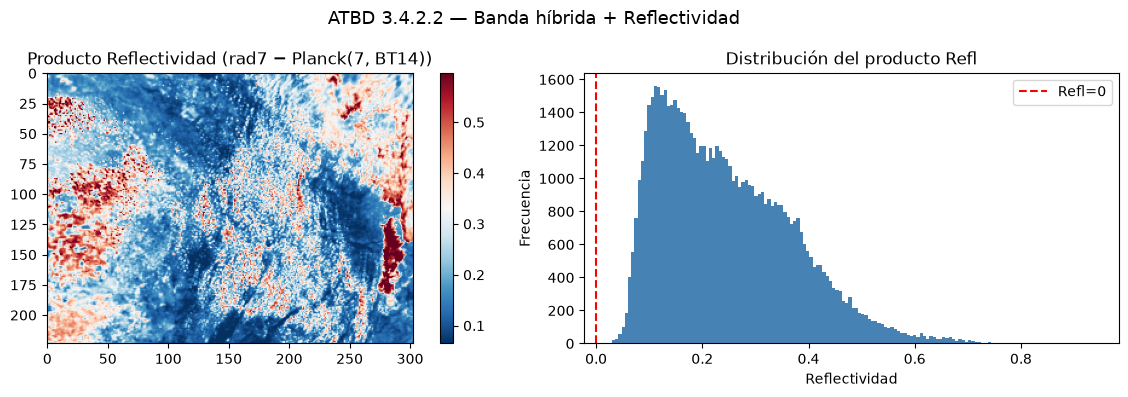

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

refl_plot = refl.copy()
im0 = axes[0].imshow(refl_plot, cmap='RdBu_r', origin='upper',
                     vmin=np.nanpercentile(refl_plot, 1),
                     vmax=np.nanpercentile(refl_plot, 99))
plt.colorbar(im0, ax=axes[0])
axes[0].set_title('Producto Reflectividad (rad7 − Planck(7, BT14))')

axes[1].hist(refl_plot[np.isfinite(refl_plot)].ravel(), bins=150, color='steelblue', edgecolor='none')
axes[1].set_xlabel('Reflectividad')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución del producto Refl')
axes[1].axvline(0, color='red', linestyle='--', label='Refl=0')
axes[1].legend()

plt.suptitle('ATBD 3.4.2.2 — Banda híbrida + Reflectividad', fontsize=13)
plt.tight_layout()
plt.show()

---
## ATBD 3.4.2.3: Tests de geometría y nube. PRIMER FILTRO GRUESO.

Aplicamos los filtros de **descarte rápido** sobre toda la grilla y asignamos un código en `fire_mask`. Mostramos cuántos píxeles quedan en cada categoría.

In [75]:
# ── ATBD 3.4.2.3 — Test data against thresholds──────────────────────────
fire_mask = np.full((L, W), FireMask.FIRE_FREE, dtype=np.int32) 
cloud_mask = np.zeros((L, W), dtype=bool)

# 1. Space (NaN en BT7) 
space = np.isnan(inp.bt7)
fire_mask[space] = FireMask.SPACE

remaining = fire_mask == FireMask.FIRE_FREE

# 2. Local zenith angle
zenith_block = remaining & (inp.lza > MAX_LOCAL_ZENITH)
fire_mask[zenith_block] = FireMask.ZENITH_BLOCK

remaining = fire_mask == FireMask.FIRE_FREE

# 3. Sun glint 
glint_block = remaining & ((inp.lza < GLINT_THRESHOLD) | (inp.glint_angle < GLINT_THRESHOLD))
fire_mask[glint_block] = FireMask.GLINT_BLOCK

is_day = (inp.sza >= 0.0) & (inp.sza <= MAX_SZA_DAYLIGHT)
# 3b. Canal 14 faltante (ATBD 3.4.2.3, código 121)
miss14 = remaining & np.isnan(bt14_eff)
fire_mask[miss14] = FireMask.MISS_CH14
remaining = fire_mask == FireMask.FIRE_FREE

# 4. Saturation / unusable temperatures
sat7 = remaining & (inp.bt7 > SAT_TEMP_CH7 + SAT_BUFF)
fire_mask[sat7] = FireMask.SAT_CH7
remaining = fire_mask == FireMask.FIRE_FREE

sat14 = remaining & (bt14_eff > SAT_TEMP_CH14 + SAT_BUFF)
fire_mask[sat14] = FireMask.SAT_CH14
remaining = fire_mask == FireMask.FIRE_FREE

unus7 = remaining & (inp.bt7 < MIN_BT)
fire_mask[unus7] = FireMask.UNUS_CH7
remaining = fire_mask == FireMask.FIRE_FREE

unus14 = remaining & (bt14_eff < MIN_BT)
fire_mask[unus14] = FireMask.UNUS_CH14
remaining = fire_mask == FireMask.FIRE_FREE

# 5. Radiance quality
neg_rad = remaining & ((inp.rad7 < 0) | (rad14_eff < 0))
fire_mask[neg_rad] = FireMask.NEG_RAD
remaining = fire_mask == FireMask.FIRE_FREE

# 6. Ecosystem masks
# Pixeles donde no se deberia buscar incendios porque son agua o desierto brillante

#implementacion anterior
#bad_eco = remaining & (np.isin(inp.land_cover, MODIS_WATER_CODES)| (inp.land_cover == UMD_WATER_CODE) | (inp.desert_mask == DESERT_BRIGHT))
#fire_mask[bad_eco] = FireMask.BAD_ECOSYSTEM # Este filtro dice que se aplica a los vecinos tambien, faltaria ver eso
#remaining = fire_mask == FireMask.FIRE_FREE

#sea = remaining & (inp.usgs_eco == USGS_SEA_WATER)
#fire_mask[sea] = FireMask.SEA_WATER
#remaining = fire_mask == FireMask.FIRE_FREE

#coast = remaining & np.isin(inp.usgs_eco, USGS_COAST_FRINGE)
#fire_mask[coast] = FireMask.COAST_FRINGE
#remaining = fire_mask == FireMask.FIRE_FREE

#inland = remaining & np.isin(inp.usgs_eco, USGS_INLAND_WATER)
#fire_mask[inland] = FireMask.INLAND_WATER
#remaining = fire_mask == FireMask.FIRE_FREE

#parche

# ── Ecosystem / surface mask tests (ATBD 3.4.2.3) ────
# Códigos 150/151/152/153 tomados directamente de eco_mask_fixed.

import numpy as np
eco_mask = np.load("/Users/valentinachagas/Documents/GitHub/GERIS-PFC/implementacion/mask_example.npy")   # o la ruta que corresponda

eco_mask_fixed = eco_mask.astype(np.uint8)

bad_eco = remaining & (eco_mask_fixed == FireMask.BAD_ECOSYSTEM)
fire_mask[bad_eco] = FireMask.BAD_ECOSYSTEM
remaining = fire_mask == FireMask.FIRE_FREE

sea = remaining & (eco_mask_fixed == FireMask.SEA_WATER)

coast = remaining & (eco_mask_fixed == FireMask.COAST_FRINGE)

inland = remaining & (eco_mask_fixed == FireMask.INLAND_WATER)

# 7. Minimum BT difference (ATBD: primero fire-free/100, después too-cold/201)
diff = inp.bt7 - bt14_eff
fire_free = (remaining & (np.abs(diff) <= CH_DIFF) & ((inp.bt7 > BRIGHTNESS_THRESHOLD) | (bt14_eff > BRIGHTNESS_THRESHOLD)))
fire_mask[fire_free] = FireMask.FIRE_FREE
remaining = fire_mask == FireMask.FIRE_FREE

too_cold = (remaining & (np.abs(diff) < CH_DIFF) & ((inp.bt7 <= BRIGHTNESS_THRESHOLD) | (bt14_eff <= BRIGHTNESS_THRESHOLD)))
fire_mask[too_cold] = FireMask.TOO_COLD
remaining = fire_mask == FireMask.FIRE_FREE

# 8. Dynamic thresholds que dependen de la hora del día
bt7_min = np.full(inp.bt7.shape, BT7_MIN_NIGHT)
bt7_refl_thr = np.full(inp.bt7.shape, BT7_REFL_THRESH_NIGHT)

cos_sza = np.cos(np.deg2rad(inp.sza))

bt7_min[is_day] = BT7_MIN_NIGHT + BT7_MIN_SOLAR_COEF * cos_sza[is_day]
bt7_refl_thr[is_day] = BT7_REFL_THRESH_NIGHT + BT7_REFL_THRESH_SOLAR * cos_sza[is_day]


# 9. Cloud tests
# los tests de nube NO sacan al píxel de carrera (ATBD 3.4.2.3)
cloud_bt14 = remaining & (bt14_eff < CLOUD_BT14_THRESH)
fire_mask[cloud_bt14] = FireMask.CLOUD_BT14
cloud_mask[cloud_bt14] = True

cloud_bt7_bt14_neg = remaining & ((inp.bt7 - bt14_eff) < CLOUD_BT7_BT14_NEG)
fire_mask[cloud_bt7_bt14_neg] = FireMask.CLOUD_BT7_BT14_NEG 
cloud_mask[cloud_bt7_bt14_neg] = True

cloud_bt7_bt14_pos = remaining & ((inp.bt7 - bt14_eff) > CLOUD_BT7_BT14_POS) & (inp.bt7 < CLOUD_BT7_FOR_POS)
fire_mask[cloud_bt7_bt14_pos] = FireMask.CLOUD_BT7_BT14_POS
cloud_mask[cloud_bt7_bt14_pos] = True

cloud_albedo = np.zeros((L, W), dtype=bool)
if inp.refl2 is not None:
    geom = ((inp.sza <= 70) | ((inp.sza <= 60) & (inp.lza <= 60)))
    cloud_albedo = remaining & is_day & geom & np.isfinite(albedo) & (albedo > CLOUD_ALBEDO_THRESH)
    fire_mask[cloud_albedo] = FireMask.CLOUD_ALBEDO
    cloud_mask[cloud_albedo] = True

cloud_bt15        = np.zeros((L, W), dtype=bool)
cloud_bt1415_neg  = np.zeros((L, W), dtype=bool)
cloud_bt1415_pos  = np.zeros((L, W), dtype=bool)
if inp.bt15 is not None:
    cloud_bt15 = remaining & (inp.bt15 <= CLOUD_BT15_THRESH)
    fire_mask[cloud_bt15] = FireMask.CLOUD_BT15
    cloud_mask[cloud_bt15] = True

    diff15 = bt14_eff - inp.bt15
    scope15 = remaining & (bt14_eff < CLOUD_BT14_THRESH)

    cloud_bt1415_neg = scope15 & (diff15 < CLOUD_BT14_BT15_NEG)
    fire_mask[cloud_bt1415_neg] = FireMask.CLOUD_BT14_BT15_NEG
    cloud_mask[cloud_bt1415_neg] = True

    cloud_bt1415_pos = scope15 & (diff15 > CLOUD_BT14_BT15_POS)
    fire_mask[cloud_bt1415_pos] = FireMask.CLOUD_BT14_BT15_POS
    cloud_mask[cloud_bt1415_pos] = True

remaining = fire_mask == FireMask.FIRE_FREE

# 'remaining' NO se reduce por los tests de nube: los pixeles nublados siguen
# en carrera para 3.4.2.4 y las etapas siguientes ("cloudy pixels MAY be
# found to contain fires later", ATBD 3.4.2.3)
categories = {
    'SPACE'                    : int(space.sum()),
    'ZENITH_BLOCK'             : int(zenith_block.sum()),
    'GLINT_BLOCK (bruto)*'     : int(glint_block.sum()),
    'MISS_CH14'                : int(miss14.sum()),
    'SAT_CH7'                  : int(sat7.sum()),
    'SAT_CH14'                 : int(sat14.sum()),
    'UNUS_CH7'                 : int(unus7.sum()),
    'UNUS_CH14'                : int(unus14.sum()),
    'BAD_ECOSYSTEM'            : int(bad_eco.sum()),
    'SEA_WATER'                : int(sea.sum()),
    'COAST_FRINGE'             : int(coast.sum()),
    'INLAND_WATER'             : int(inland.sum()),
    'NEG_RAD'                  : int(neg_rad.sum()),
    'FIRE_FREE'                : int(fire_free.sum()),
    'TOO_COLD'                 : int(too_cold.sum()),
    'CLOUD (union, algun test)': int(cloud_mask.sum()),
    '  · CLOUD_BT14'           : int(cloud_bt14.sum()),
    '  · CLOUD_BT7-BT14 neg'   : int(cloud_bt7_bt14_neg.sum()),
    '  · CLOUD_BT7-BT14 pos'   : int(cloud_bt7_bt14_pos.sum()),
    '  · CLOUD_ALBEDO'         : int(cloud_albedo.sum()),
    '  · CLOUD_BT15'           : int(cloud_bt15.sum()),
    '  · CLOUD_BT14-BT15 neg'  : int(cloud_bt1415_neg.sum()),
    '  · CLOUD_BT14-BT15 pos'  : int(cloud_bt1415_pos.sum()),
    'Candidatos restantes ("remaining")': int(remaining.sum()),
}

df_geo = pd.DataFrame(categories.items(), columns=['Estado', 'N pixeles'])
df_geo['% total'] = (df_geo['N pixeles'] / (L * W) * 100).round(2)
print(df_geo.to_string(index=False))


                            Estado  N pixeles  % total
                             SPACE          0     0.00
                      ZENITH_BLOCK          0     0.00
              GLINT_BLOCK (bruto)*          0     0.00
                         MISS_CH14          0     0.00
                           SAT_CH7          0     0.00
                          SAT_CH14          0     0.00
                          UNUS_CH7          0     0.00
                         UNUS_CH14          0     0.00
                     BAD_ECOSYSTEM        225     0.33
                         SEA_WATER          0     0.00
                      COAST_FRINGE          0     0.00
                      INLAND_WATER        852     1.26
                           NEG_RAD          0     0.00
                         FIRE_FREE       1088     1.60
                          TOO_COLD          0     0.00
         CLOUD (union, algun test)       4783     7.05
                      · CLOUD_BT14       2451     3.61
          

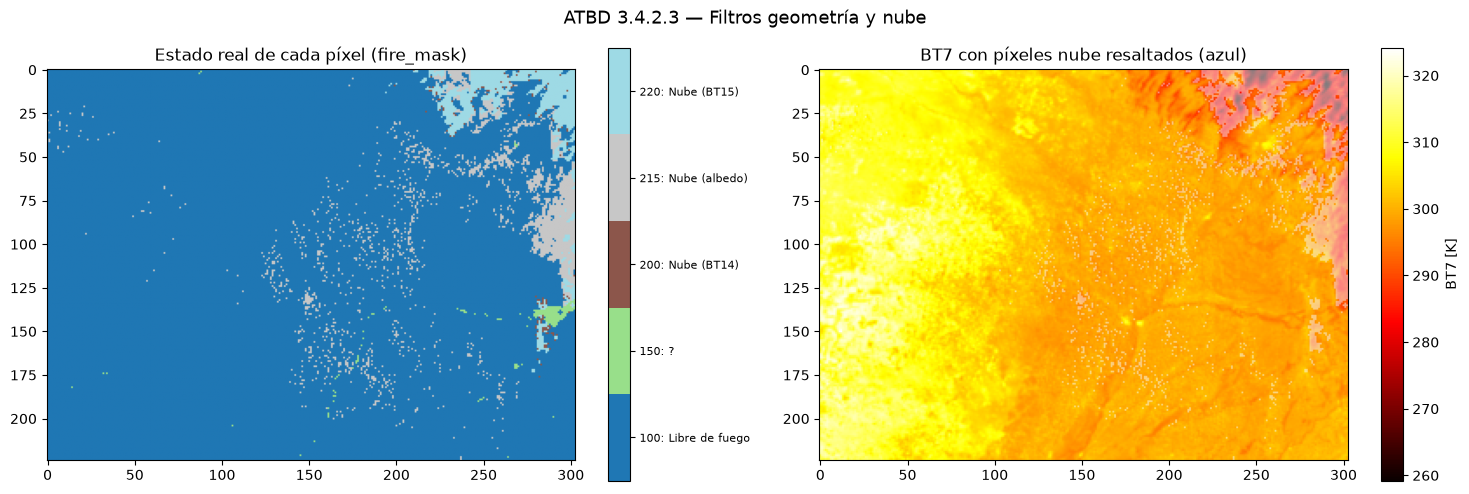

In [76]:
# Construimos el mapa de estado directamente desde fire_mask 
codes_present = sorted(np.unique(fire_mask).tolist())

code_names = {
    FireMask.SPACE: 'Espacio',
    FireMask.ZENITH_BLOCK: 'Zenith',
    FireMask.GLINT_BLOCK: 'Glint',
    FireMask.CLOUD_BT14: 'Nube (BT14)',
    FireMask.CLOUD_BT7_BT14_NEG: 'Nube (BT7-BT14 neg)',
    FireMask.CLOUD_BT7_BT14_POS: 'Nube (BT7-BT14 pos)',
    FireMask.CLOUD_ALBEDO: 'Nube (albedo)',
    FireMask.CLOUD_BT15: 'Nube (BT15)',
    FireMask.CLOUD_BT14_BT15_NEG: 'Nube (BT14-BT15 neg)',
    FireMask.CLOUD_BT14_BT15_POS: 'Nube (BT14-BT15 pos)',
    FireMask.SAT_CH7: 'Saturado CH7',
    FireMask.SAT_CH14: 'Saturado CH14',
    FireMask.NEG_RAD: 'Radiancia negativa',
    FireMask.UNUS_CH7: 'CH7 no usable',
    FireMask.UNUS_CH14: 'CH14 no usable',
    FireMask.FIRE_FREE: 'Libre de fuego',
    FireMask.INIT: 'INIT sin tocar',
}

n = len(codes_present)
cmap = plt.get_cmap('tab20', n)
code_to_idx = {c: i for i, c in enumerate(codes_present)}
idx_map = np.vectorize(code_to_idx.get)(fire_mask)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

im = axes[0].imshow(idx_map, cmap=cmap, vmin=-0.5, vmax=n - 0.5, origin='upper')
cbar = plt.colorbar(im, ax=axes[0], ticks=range(n))
cbar.ax.set_yticklabels([f'{c}: {code_names.get(c, "?")}' for c in codes_present], fontsize=8)
axes[0].set_title('Estado real de cada píxel (fire_mask)')

im1 = axes[1].imshow(inp.bt7, cmap='hot', origin='upper')
plt.colorbar(im1, ax=axes[1], label='BT7 [K]')
cloud_overlay = np.ma.masked_where(~cloud_mask, cloud_mask)
axes[1].imshow(cloud_overlay, cmap='Blues', alpha=0.5, origin='upper')
axes[1].set_title('BT7 con píxeles nube resaltados (azul)')

plt.suptitle('ATBD 3.4.2.3 — Filtros geometría y nube', fontsize=13)
plt.tight_layout()
plt.show()

---
## ATBD 3.4.2.4: Test along-scan de reflectividad + flag de saturación

Antes de calcular el background, el algoritmo aplica un **test de reflectividad along-scan**: compara el producto `Refl` del píxel actual con el de los píxeles ubicados 3 posiciones a la izquierda (`Refl-3`) y 3 a la derecha (`Refl+3`) en la misma línea de escaneo, para detectar bordes de nube cercanos. Actúa como un filtro de nubes y bordes de nubes que podrían confundirse con incendios debido a su alta reflectividad.

- **Nocturno** (o diurno sin albedo válido): si `BT7 < BT7_min` y `BT7 ≥ MIN_BT`, y (`Refl-3 < 0.2` o `Refl+3 < 0.2`) → `FireMask.ALONG_SCAN_NIGHT` (código 240), el píxel se descarta.
- **Diurno** (con albedo válido): si `Albedo ≥ 0.38` y `BT7 < 320 K`, y (`Refl-3 < 0.2` o `Refl+3 < 0.2`) → `FireMask.ALONG_SCAN_DAY` (código 245), el píxel se descarta.

**Importante:** este test corre sobre los píxeles que pasaron los filtros rápidos, *incluyendo los marcados como nube* en §3.4.2.3 — el ATBD dice explícitamente que esos píxeles "pueden ser encontrados como fuego más adelante", así que todavía no se descartan. 

Inmediatamente después (todavía dentro del texto de la sección 3.4.2.4 del ATBD, antes de pasar a 3.4.2.5) se evalúa el **flag de saturación**: si `BT7 ≥ SAT_FLAG_CH7` (411.76 K) o `BT14 ≥ SAT_FLAG_CH14` (339.90 K) se marca `sat_flag=True` y se asigna `FailChar = 7` (Tabla 3.5). A diferencia del test `SAT_CH7`/`SAT_CH14` de la sección 3.4.2.3 (que usa un buffer de 5 K y **descarta** el píxel), este umbral es más ajustado (saturación real − 0.1 K) y **no descarta** el píxel — sólo lo marca para saltarse más adelante la caracterización sub-píxel (Dozier).


In [77]:
# Vecinos a 3 posiciones en la misma fila (scan), con clamp de borde (no wrap-around) para no unir erroneamente este con oeste
idx        = np.arange(W)
idx_left   = np.clip(idx - 3, 0, W - 1)
idx_right  = np.clip(idx + 3, 0, W - 1)
refl_left  = refl[:, idx_left]
refl_right = refl[:, idx_right]

# Rama diurna vs. nocturna: mutuamente excluyentes
# En la documentacion no se aclara qué se hace si es de día pero refl no está disponible
night_test = remaining & ~is_day & (inp.bt7 < bt7_min) & (inp.bt7 >= MIN_BT7) 
day_test   = remaining &  is_day & np.isfinite(albedo) & (albedo >= CLOUD_ALBEDO_THRESH) & (inp.bt7 < MAX_BT7)

suspicious_neighbour = (refl_left < MIN_REFL) | (refl_right < MIN_REFL)

along_scan_night = night_test & suspicious_neighbour
fire_mask[along_scan_night] = FireMask.ALONG_SCAN_NIGHT

along_scan_day = day_test & suspicious_neighbour
fire_mask[along_scan_day] = FireMask.ALONG_SCAN_DAY

# Estos códigos sí sacan al píxel de carrera (ATBD: "proceeds to the next pixel")
remaining = remaining & ~(along_scan_night | along_scan_day) # PERO no hay que hacer INIT, porque eso borraria nubes

# ── Flag de saturacion + FailChar = 7 (todavia ATBD 3.4.2.4) ───────────────
fail_char = np.full((L, W), FailChar.NONE, dtype=np.int32)

sat_flag = remaining & ((inp.bt7 >= SAT_FLAG_CH7) | (bt14_eff >= SAT_FLAG_CH14))
fail_char[sat_flag] = FailChar.F7

# ── Resumen ────────────────────────────────────────────────────────────────
categories_342_4 = {
    'Elegibles (día)'                      : int(day_test.sum()),
    'Elegibles (noche)'                    : int(night_test.sum()),
    'ALONG_SCAN_DAY (código 245)'          : int(along_scan_day.sum()),
    'ALONG_SCAN_NIGHT (código 240)'        : int(along_scan_night.sum()),
    'Candidatos restantes tras 3.4.2.4'    : int(remaining.sum()),
}
df_scan = pd.DataFrame(categories_342_4.items(), columns=['Estado', 'N píxeles'])
df_scan['% total'] = (df_scan['N píxeles'] / (L * W) * 100).round(2)
print(df_scan.to_string(index=False))

                           Estado  N píxeles  % total
                  Elegibles (día)          0     0.00
                Elegibles (noche)          0     0.00
      ALONG_SCAN_DAY (código 245)          0     0.00
    ALONG_SCAN_NIGHT (código 240)          0     0.00
Candidatos restantes tras 3.4.2.4      62864    92.62


---
## ATBD 3.4.2.5: Background condition statistics

background.py es la implementación de ATBD §3.4.2.5: dado un píxel candidato, calcula "cómo se ve normalmente esa zona" (el fondo/background) para poder después decir si el píxel en cuestión se desvía lo suficiente como para sospechar fuego (eso ya es §3.4.2.6, que consume esta salida).

Para un píxel candidato de ejemplo, el algoritmo calcula estadísticas de fondo en una
**ventana dinámica** centrada en el píxel:

- Empieza en `half=5` (ventana 11×11) y se agranda de a `+5` en cada dirección por
  iteración, hasta un máximo de 10 iteraciones (ventana final 111×111).
- Un píxel de la ventana es **válido** si:
  - es tierra (`land_mask`),
  - **no** es anómalamente cálido: `BT7 > 310K` (`+25·cos(SZA)` de día),
  - **no** es frío: `BT7 < 270K` o `BT14 < 270K`,
  - y **no** es "reflectivo/nube": `vis < 1` (8-bit) o `Albedo ≥ 0.38`.
- Los píxeles fuera de imagen (borde) **cuentan en el denominador** de la ventana pero
  nunca son válidos (así, cerca del borde, converge más lento).
- Se agranda la ventana hasta que **>= 20%** de las posiciones de la ventana son válidas.
  Si se llega a 10 iteraciones sin lograrlo: `FireMask.NO_BACKGROUND` (código 170) y se
  pasa al siguiente píxel.
- Una vez satisfecho el 20%, se calculan dos enfoques para la media/std de BT7 y BT14:
  - **Estadístico**: media/std directas sobre los valores válidos.
  - **Histograma**: se arma un histograma de enteros de BT7−BT14, se toma el bin con
    mayor frecuencia ± 1 vecino, y se calcula media/std sobre ese subconjunto.
  - Se usa el enfoque con **menor std de BT7** para definir `Temp7_Bkg_Mean`,
    `Temp14_Bkg_Mean` y `Vis_Mean_Bkg` (Tabla 3.6).

**Nota:** el ATBD menciona un "offset = min(5, n_passes/3)" para ajustar por tamaño de
ventana, pero ese ajuste **no se aplica acá** — se aplica más adelante, en
`_contextual_thresholds` (§3.4.2.6), usando el `n_passes` que devuelve este paso.

In [78]:
# elegimos un pixel de ejemplo 
np.random.seed(7)
candidatos_342_5 = np.argwhere(remaining)
i0, j0 = candidatos_342_5[np.random.randint(len(candidatos_342_5))]
i0, j0 = int(i0), int(j0)

print(f'Pixel de ejemplo: (i={i0}, j={j0})  |  BT7={inp.bt7[i0,j0]:.1f}K  BT14={bt14_eff[i0,j0]:.1f}K  '
      f'is_day={bool(is_day[i0,j0])}')

trace = []
bkg = compute_background(
    i0, j0, inp.bt7, bt14_eff, refl, vis_brightness,
    albedo if inp.refl2 is not None else None,
    inp.land_mask, sza_cos, is_day,
    trace=trace,
)

if bkg is None:
    print("No se pudo calcular el fondo para el píxel de ejemplo.")


Pixel de ejemplo: (i=219, j=262)  |  BT7=300.3K  BT14=291.9K  is_day=True


In [79]:
# Conectar el trace con el resultado final devuelto por compute_background 
enfoques = trace[-1]
usar_hist = enfoques['t7_hist_std'] < enfoques['t7_stat_std']
metodo = 'histograma' if usar_hist else 'estadistico'

print(f"Metodo elegido (menor std BT7): {metodo}")
print(f"  bkg.temp7_bkg_mean   = {bkg.temp7_bkg_mean:.2f} K")
print(f"  bkg.temp14_bkg_mean  = {bkg.temp14_bkg_mean:.2f} K")
print(f"  bkg.temp7_bkg_stddev = {bkg.temp7_bkg_stddev:.3f}")
print(f"  bkg.n_passes         = {bkg.n_passes}   (offset en 3.4.2.6 = min(5, n_passes/3) = {min(5, bkg.n_passes/3):.2f})")
print(f"  bkg.reflb            = {bkg.reflb:.4f}   (ventana completa, sin filtrar)")
print(f"  bkg.rad_diff_sigma   = {bkg.rad_diff_sigma:.4f}")

# Sanity check liviano: el metodo elegido en el trace coincide con lo que devolvio bkg
esperado_t7 = enfoques['t7_hist_mean'] if usar_hist else enfoques['t7_stat_mean']
assert abs(bkg.temp7_bkg_mean - esperado_t7) < 1e-4, "El metodo elegido en el trace no coincide con bkg.temp7_bkg_mean"
print("\n✅ bkg.temp7_bkg_mean coincide con el enfoque elegido segun el trace")

Metodo elegido (menor std BT7): histograma
  bkg.temp7_bkg_mean   = 299.29 K
  bkg.temp14_bkg_mean  = 296.01 K
  bkg.temp7_bkg_stddev = 1.104
  bkg.n_passes         = 0   (offset en 3.4.2.6 = min(5, n_passes/3) = 0.00)
  bkg.reflb            = 0.2221   (ventana completa, sin filtrar)
  bkg.rad_diff_sigma   = 0.1135

✅ bkg.temp7_bkg_mean coincide con el enfoque elegido segun el trace


In [80]:
df_iter = pd.DataFrame(trace[:-1])
print(df_iter.to_string(index=False))

 n_iter  half  window_size  n_valid  frac_valid  cumple_20pct
      0     5          121      109    0.900826          True


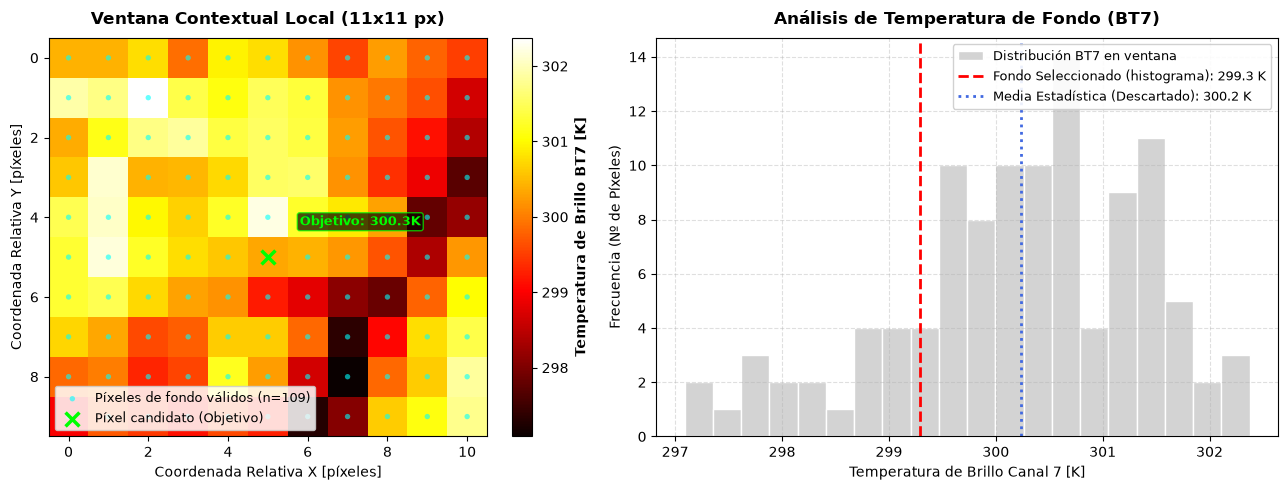

In [81]:
import numpy as np
import matplotlib.pyplot as plt

i_lo, i_hi, j_lo, j_hi = enfoques['valid_bounds']
valid = enfoques['valid_mask']
vi, vj = np.where(valid)

# Crear figura con mejor resolución (dpi)
fig, ax = plt.subplots(1, 2, figsize=(14, 5), dpi=100)

# ---------------------------------------------------------
# SUBPLOT 1: Ventana espacial
# ---------------------------------------------------------
im = ax[0].imshow(inp.bt7[i_lo:i_hi+1, j_lo:j_hi+1], cmap='hot', origin='upper')

# Añadir barra de color para dar contexto térmico al mapa
cbar = fig.colorbar(im, ax=ax[0], fraction=0.046, pad=0.04)
cbar.set_label('Temperatura de Brillo BT7 [K]', fontsize=10, fontweight='bold')

# Píxeles válidos y objetivo con etiquetas descriptivas
ax[0].scatter(vj, vi, s=15, c='cyan', alpha=0.6, edgecolors='none', 
              label=f'Píxeles de fondo válidos (n={valid.sum()})')

i_obj, j_obj = j0 - j_lo, i0 - i_lo
ax[0].scatter([i_obj], [j_obj], s=100, c='lime', marker='x', linewidths=2.5, 
              label='Píxel candidato (Objetivo)')

# Anotación directa sobre el píxel objetivo
val_target = inp.bt7[i0, j0]
ax[0].annotate(f'Objetivo: {val_target:.1f}K', 
                xy=(i_obj, j_obj), xytext=(i_obj + 0.8, j_obj - 0.8),
                color='lime', fontweight='bold', fontsize=9,
                bbox=dict(boxstyle="round,pad=0.2", fc="black", alpha=0.7, ec="lime"))

ax[0].set_title(f"Ventana Contextual Local ({bkg.half_width*2+1}x{bkg.half_width*2+1} px)", 
                fontsize=12, fontweight='bold', pad=10)
ax[0].set_xlabel("Coordenada Relativa X [píxeles]", fontsize=10)
ax[0].set_ylabel("Coordenada Relativa Y [píxeles]", fontsize=10)
ax[0].legend(fontsize=9, loc='lower left', framealpha=0.85)
ax[0].grid(False)


# ---------------------------------------------------------
# SUBPLOT 2: Histograma de temperaturas
# ---------------------------------------------------------
n, bins, patches = ax[1].hist(enfoques['bt7_vals'], bins=20, color='lightgray', 
                              edgecolor='white', label='Distribución BT7 en ventana')

# Líneas de referencia con descripciones claras en la leyenda
val_elegido = bkg.temp7_bkg_mean
val_est = enfoques['t7_stat_mean']

ax[1].axvline(val_elegido, color='red', linestyle='--', linewidth=2,
              label=f'Fondo Seleccionado ({metodo}): {val_elegido:.1f} K')
ax[1].axvline(val_est, color='royalblue', linestyle=':', linewidth=2,
              label=f'Media Estadística (Descartado): {val_est:.1f} K')

# Anotación contextual indicando la discrepancia si existen ambas
diff = abs(val_elegido - val_est)
ax[1].set_title('Análisis de Temperatura de Fondo (BT7)', fontsize=12, fontweight='bold', pad=10)
ax[1].set_xlabel('Temperatura de Brillo Canal 7 [K]', fontsize=10)
ax[1].set_ylabel('Frecuencia (Nº de Píxeles)', fontsize=10)
ax[1].legend(fontsize=9, loc='upper right', framealpha=0.9)
ax[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [82]:
from fdca.background import compute_background
from tqdm import tqdm

bkg_map = np.full((L, W), None, dtype=object)

# Solo calculamos background para píxeles que siguen "vivos" tras 3.4.2.1-3.4.2.4
# (igual que part1.py: el resto nunca llega a esta sección del algoritmo).
# Sin trace: para todo el dominio, trace es demasiado pesado en memoria —
# trace queda reservado para la celda de inspección de un píxel de ejemplo.
coords_vivos = np.argwhere(remaining)

for i, j in tqdm(coords_vivos, desc="3.4.2.5 — background para píxeles vivos"):
    i, j = int(i), int(j)

    bkg = compute_background(
        i, j, inp.bt7, bt14_eff, refl, vis_brightness,
        albedo if inp.refl2 is not None else None,
        inp.land_mask, sza_cos, is_day,
    )

    if bkg is None:
        fire_mask[i, j] = FireMask.NO_BACKGROUND
        remaining[i, j] = False
        continue

    bkg_map[i, j] = bkg

print(f"Background calculado para {int((bkg_map != None).sum()):,} de {len(coords_vivos):,} píxeles vivos")


3.4.2.5 — background para píxeles vivos: 100%|██████████| 62864/62864 [01:46<00:00, 589.01it/s]

Background calculado para 62,854 de 62,864 píxeles vivos


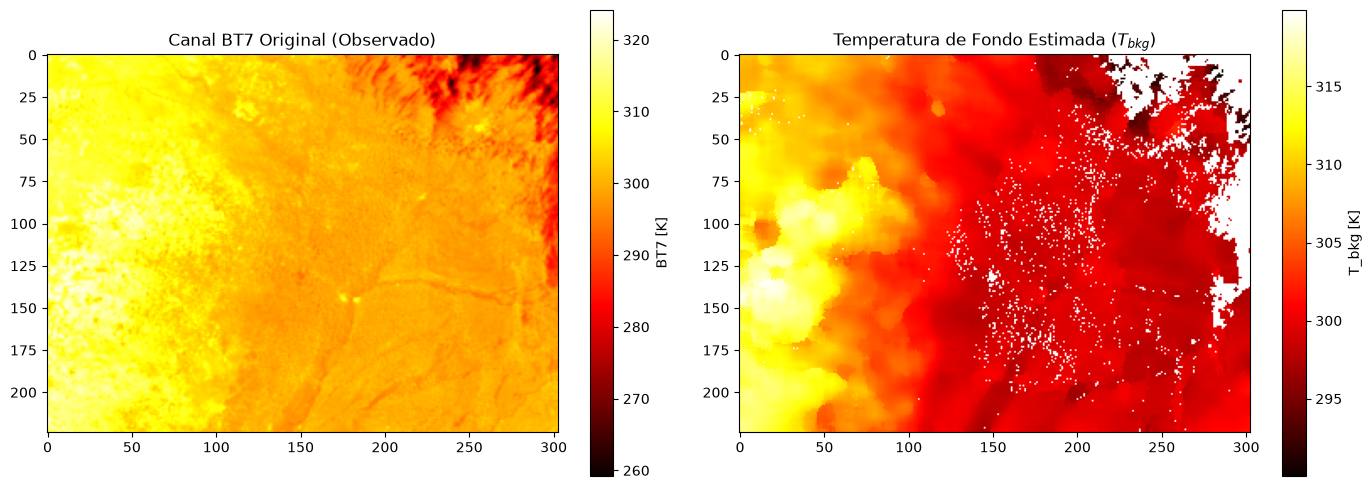

In [83]:
import matplotlib.pyplot as plt
import numpy as np

# Extraer solo la temperatura elegida de cada objeto 'bkg'
bkg_temp_grid = np.full(inp.bt7.shape, np.nan)

for (i, j), bkg in np.ndenumerate(bkg_map):
    if bkg is not None:
        bkg_temp_grid[i, j] = bkg.temp7_bkg_mean

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Canal BT7 original (con píxeles candidatos)
im0 = ax[0].imshow(inp.bt7, cmap='hot')
ax[0].set_title("Canal BT7 Original (Observado)")
fig.colorbar(im0, ax=ax[0], label="BT7 [K]")

# Temperatura de fondo calculada
im1 = ax[1].imshow(bkg_temp_grid, cmap='hot')
ax[1].set_title("Temperatura de Fondo Estimada ($T_{bkg}$)")
fig.colorbar(im1, ax=ax[1], label="T_bkg [K]")

plt.tight_layout()
plt.show()

Muestra la superficie continua de temperaturas de fondo estimadas en todo el dominio espacial. Permite verificar a simple vista si el fondo refleja la gradiente térmica natural de la zona (ej. zonas más frías por vegetación/agua vs. zonas más cálidas por suelo desnudo/desierto).

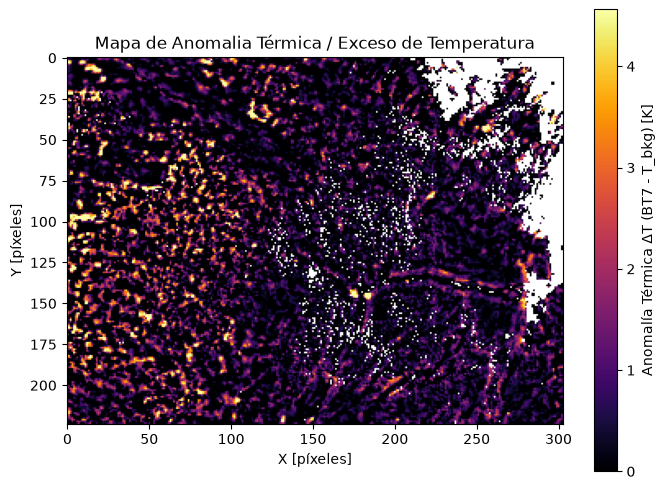

In [84]:
# Calcular el delta de temperatura para los píxeles analizados
delta_t = inp.bt7 - bkg_temp_grid

plt.figure(figsize=(8, 6))
im = plt.imshow(delta_t, cmap='inferno', vmin=0, vmax=np.nanpercentile(delta_t, 99))
cbar = plt.colorbar(im, label="Anomalía Térmica ΔT (BT7 - T_bkg) [K]")
plt.title("Mapa de Anomalia Térmica / Exceso de Temperatura")
plt.xlabel("X [píxeles]")
plt.ylabel("Y [píxeles]")
plt.show()

Esta es la visualización más relevante para detección de incendios o anomalias térmicas. Muestra la diferencia entre la temperatura real observada por el satélite y la temperatura de fondo esperada.Los píxeles con $\Delta T \approx 0\text{ K}$ son fondo normal.Los píxeles con $\Delta T$ alto destacan claramente como verdaderos focos de calor/anomalías.

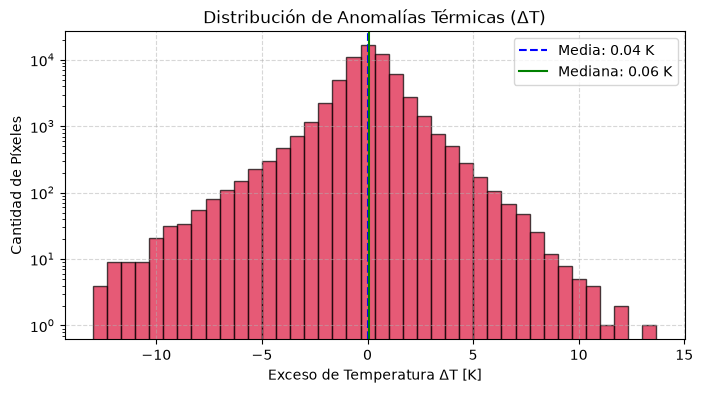

In [85]:
valid_deltas = delta_t[~np.isnan(delta_t)]

plt.figure(figsize=(8, 4))
plt.hist(valid_deltas, bins=40, color='crimson', edgecolor='black', alpha=0.7)
plt.axvline(np.mean(valid_deltas), color='blue', linestyle='--', label=f'Media: {np.mean(valid_deltas):.2f} K')
plt.axvline(np.median(valid_deltas), color='green', linestyle='-', label=f'Mediana: {np.median(valid_deltas):.2f} K')

plt.title("Distribución de Anomalías Térmicas (ΔT)")
plt.xlabel("Exceso de Temperatura ΔT [K]")
plt.ylabel("Cantidad de Píxeles")
plt.yscale('log') # Escala logarítmica para ver fácilmente valores extremos/anomalías
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Ayuda a mostrar cuantitativamente la distribución de las anomalías en el conjunto total de píxeles procesados.

In [86]:
total_vivos = len(coords_vivos)
exitosos = np.count_nonzero(bkg_map != None)
fallidos = total_vivos - exitosos

print("="*50)
print(" RESUMEN DE CÁLCULO DE FONDO CONTEXTUAL (SECTION 3.4.2.5)")
print("="*50)
print(f"• Píxeles candidatos evaluados: {total_vivos:,}")
print(f"• Fondos calculados con éxito : {exitosos:,} ({exitosos/total_vivos*100:.1f}%)")
print(f"• Rechazados/Sin fondo (NO_BKG): {fallidos:,} ({fallidos/total_vivos*100:.1f}%)")

if exitosos > 0:
    deltas = delta_t[~np.isnan(delta_t)]
    print(f"• ΔT Promedio                  : {np.mean(deltas):.2f} K")
    print(f"• ΔT Máximo                    : {np.max(deltas):.2f} K")
print("="*50)

 RESUMEN DE CÁLCULO DE FONDO CONTEXTUAL (SECTION 3.4.2.5)
• Píxeles candidatos evaluados: 62,864
• Fondos calculados con éxito : 62,854 (100.0%)
• Rechazados/Sin fondo (NO_BKG): 10 (0.0%)
• ΔT Promedio                  : 0.04 K
• ΔT Máximo                    : 13.68 K


## ATBD 3.4.2.6

### Determine Contextual Thresholds 

> Esta sección define la **regla de decisión**: *¿Qué tan "caliente" o "brillante" debe ser un píxel para dejar de considerarlo terreno normal y clasificarlo como un posible incendio?*


### 1. El Concepto de "Ruido de Fondo"
En la sección previa (`3.4.2.5`), calculaste la **media** ($\mu$) y la **desviación estándar** ($\sigma$) de los vecinos. Ahora usamos esa variación para definir un **margen de seguridad**:

* **Entorno uniforme ($\sigma$ baja):** El margen es pequeño; cualquier anomalía destaca rápidamente.
* **Entorno heterogéneo ($\sigma$ alta):** Terrenos mezclados (ej. rocas y vegetación) requieren un margen mayor para evitar falsas alarmas.



### 2. ¿Por qué se usan Multiplicadores? ($N \times \sigma$)
El algoritmo multiplica la desviación estándar por factores de corte (ej. $3.0\sigma$ o $3.75\sigma$).

$$\text{Umbral} = \mu_{\text{bkg}} + (k \cdot \sigma_{\text{bkg}})$$

* **Interpretación:** *"No me avises si el píxel es solo un poco más caliente que el promedio. Avísame solo si es al menos 3 o 4 veces más raro que la variación natural del paisaje."*


### 3. Límites de Seguridad: Suelos y Techos

Para evitar fallos en escenarios extremos, el algoritmo acota los umbrales contextuales dentro de un rango físico controlado (ej. entre $4.0\text{ K}$ y $10.0\text{ K}$):

| Rango | Nombre | Propósito Intuitivo |
| :--- | :--- | :--- |
| **Piso / Mínimo** | *Floor* | **Evita la hipersensibilidad.** Si el terreno es perfectamente uniforme ($\sigma \approx 0$), previene que el simple ruido numérico o del sensor active una alerta de fuego. |
| **Techo / Máximo** | *Ceiling* | **Evita la ceguera.** En terrenos ultra caóticos ($\sigma$ muy alta), evita que el umbral suba tanto que termine ignorando un incendio real. |


### 4. Test *Along Scan-Line* (Detector de Picos)
Es una prueba de **contraste local inmediato**. En lugar de mirar el promedio de toda la ventana, compara el píxel objetivo con sus vecinos adyacentes a lo largo de la línea de escaneo del satélite (2 o 3 píxeles a los lados).

> **Objetivo:** Identificar fuentes de calor puntuales (focos de incendio) marcadas como "picos" térmicos, diferenciándolas de cambios térmicos graduales en el clima o en el suelo.


### 5. El Factor Solar (Albedo de Fondo)
Durante el día, la radiación solar incidente refleja en la superficie y nubes, incrementando el brillo en la banda infrarroja de $3.9\,\mu\text{m}$ (BT7).

* **Lógica del filtro:** Separa la energía reflejada por el sol del calor emitido verdaderamente por combustión. Si un píxel es brillante pero su entorno también lo es por luz solar, el algoritmo ajusta la regla para no marcarlo como fuego.


> **Conclusión de esta etapa:**  
> La sección `3.4.2.6` **no clasifica aún el fuego**; ajusta dinámicamente la sensibilidad del detector para cada píxel según su contexto espacial y solar.

In [87]:
from fdca.part1 import _contextual_thresholds, _along_scan_reflectivity_test, _background_albedo

coords_con_bkg = np.argwhere(bkg_map != None)
print(f'Píxeles con background disponible: {len(coords_con_bkg):,}')

records = []
for i, j in coords_con_bkg:
    i, j = int(i), int(j)
    bkg = bkg_map[i, j]
    sc  = sza_cos[i, j]
    day_pixel = bool(is_day[i, j])

    std_7b14b, std_7b, std_reflb, std_reflb_max = _contextual_thresholds(bkg, sc)

    bt7_refl_thr = BT7_REFL_THRESH_NIGHT + (BT7_REFL_THRESH_SOLAR * sc if day_pixel else 0)
    pass_along = _along_scan_reflectivity_test(refl, i, j, W, std_reflb, inp.bt7[i, j], bt7_refl_thr)
    alb_bkg = _background_albedo(bkg.vis_mean_bkg, sc, day_pixel)

    records.append({
        'i': i, 'j': j,
        'bt7_bkg': bkg.temp7_bkg_mean,
        'bt14_bkg': bkg.temp14_bkg_mean,
        'n_passes': bkg.n_passes,
        'std_7b': std_7b,
        'std_7b14b': std_7b14b,
        'std_reflb': std_reflb,
        'std_reflb_max': std_reflb_max,
        'pass_along': pass_along,
        'alb_bkg': alb_bkg,
    })

df_thresh = pd.DataFrame(records)
print(f'\nUmbrales contextuales calculados para {len(df_thresh):,} píxeles')
df_thresh[['bt7_bkg', 'bt14_bkg', 'n_passes', 'std_7b', 'std_7b14b',
           'std_reflb', 'std_reflb_max']].describe().round(3)

Píxeles con background disponible: 62,854

Umbrales contextuales calculados para 62,854 píxeles


,bt7_bkg,bt14_bkg,n_passes,std_7b,std_7b14b,std_reflb,std_reflb_max
count,62854.000,62854.000,62854.000,62854.000,62854.000,62854.000,62854.0
mean,303.284,297.909,0.004,5.176,3.373,0.266,2.5
std,5.671,6.128,0.129,1.788,0.927,0.046,0.0
min,290.048,271.220,0.000,4.000,0.532,0.250,2.5
25%,299.066,294.044,0.000,4.000,2.752,0.250,2.5
50%,300.371,296.812,0.000,4.000,4.000,0.250,2.5
75%,307.492,302.968,0.000,5.825,4.000,0.250,2.5
max,319.892,312.403,9.000,10.000,4.000,0.735,2.5


In [88]:
# Vista puntual: reusamos el mismo píxel de ejemplo (i0, j0) de 3.4.2.5

fila_ejemplo = df_thresh[(df_thresh.i == i0) & (df_thresh.j == j0)]
fila_ejemplo

,i,j,bt7_bkg,bt14_bkg,n_passes,std_7b,std_7b14b,std_reflb,std_reflb_max,pass_along,alb_bkg
61605,219,262,299.288055,296.006042,0,4.141645,4.0,0.340615,2.5,False,0.091102


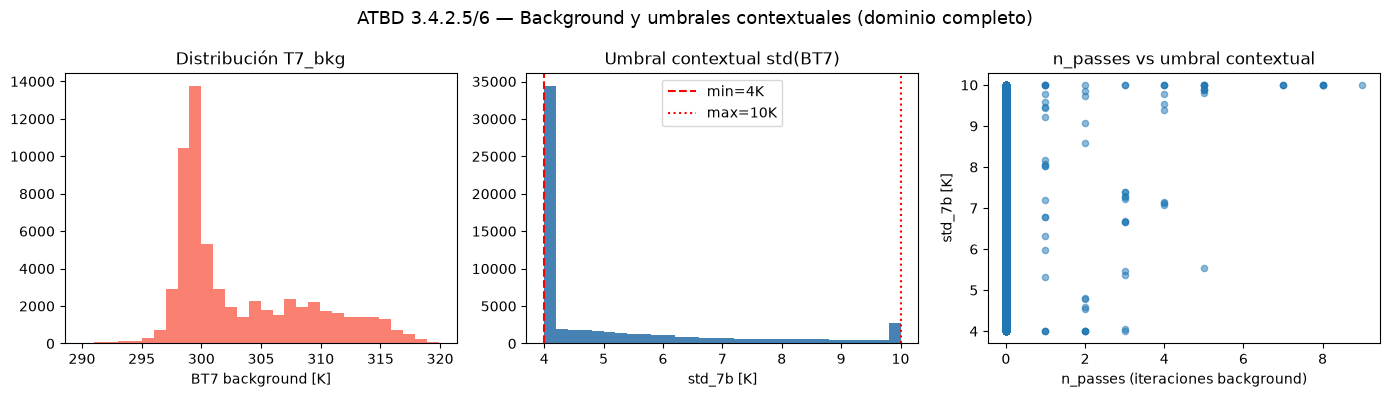

In [89]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(df_thresh['bt7_bkg'], bins=30, color='salmon', edgecolor='none')
axes[0].set_xlabel('BT7 background [K]')
axes[0].set_title('Distribución T7_bkg')

axes[1].hist(df_thresh['std_7b'], bins=30, color='steelblue', edgecolor='none')
axes[1].axvline(4.0, color='red',  linestyle='--', label='min=4K')
axes[1].axvline(10.0, color='red', linestyle=':', label='max=10K')
axes[1].set_xlabel('std_7b [K]')
axes[1].set_title('Umbral contextual std(BT7)')
axes[1].legend()

axes[2].scatter(df_thresh['n_passes'], df_thresh['std_7b'], alpha=0.5, s=20)
axes[2].set_xlabel('n_passes (iteraciones background)')
axes[2].set_ylabel('std_7b [K]')
axes[2].set_title('n_passes vs umbral contextual')

plt.suptitle('ATBD 3.4.2.5/6 — Background y umbrales contextuales (dominio completo)', fontsize=13)
plt.tight_layout()
plt.show()

---
## ATBD 3.4.2.7: Apply thresholds to identify fire pixels

Una vez calculados los umbrales contextuales (§3.4.2.6), se aplican para decidir qué píxeles
**no son fuego** y se descartan. El ATBD define tres tests en orden:

1. **Saturados o n_passes > 10:** si `(BT7-BT14 < Std_7b14b) AND (BT7-Tb3.9 < Std_7b)` → no es fuego.
2. **Non-fire test (sin flag):** `Refl < Std_reflb AND BT7 < 320K AND (BT7-BT14 < 0 OR BT7-Tb3.9 < 0)` → no es fuego.
3. **FC=1:** `(BT7-BT14 < Std_7b14b) AND (Refl < Std_reflb_max OR along_scan)` → no es fuego, `FailChar=1`.
4. **FC=2:** `(BT7-Tb3.9 < Std_7b) AND (Refl < Std_reflb_max OR along_scan)` → no es fuego, `FailChar=2`.

Los píxeles descartados acá **no** llegan a las correcciones (§3.4.2.8) ni a Dozier (§3.4.2.10).
Solo los que pasan TODOS estos tests son candidatos reales a fuego.

In [90]:
# Vectorizado sobre los pixeles 'remaining' que tienen background valido

from fdca.part1 import _contextual_thresholds, _along_scan_reflectivity_test

# Primero necesitamos los umbrales para cada pixel (ya calculados en Paso 4b)
# Usamos df_thresh que tiene std_7b, std_7b14b, std_reflb, std_reflb_max, pass_along
# Construimos arrays de umbrales para todos los pixeles con background
std_7b14b_arr = np.full((L, W), np.nan)
std_7b_arr    = np.full((L, W), np.nan)
std_reflb_arr = np.full((L, W), np.nan)
std_reflb_max_arr = np.full((L, W), np.nan)
pass_along_arr = np.zeros((L, W), dtype=bool)
bt7_bkg_arr = np.full((L, W), np.nan)

for _, row in df_thresh.iterrows():
    i, j = int(row['i']), int(row['j'])
    std_7b14b_arr[i, j] = row['std_7b14b']
    std_7b_arr[i, j]    = row['std_7b']
    std_reflb_arr[i, j] = row['std_reflb']
    std_reflb_max_arr[i, j] = row['std_reflb_max']
    pass_along_arr[i, j] = row['pass_along']
    bt7_bkg_arr[i, j] = row['bt7_bkg']

has_bkg = np.isfinite(std_7b14b_arr)

# Test 1: Saturated/max-iter quick path (sat_flag ya calculado en 3.4.2.4)
sat_or_maxiter = sat_flag  # en esta escena n_passes=0 para todos, asi que solo sat
test1 = sat_or_maxiter & has_bkg & (
    (inp.bt7 - bt14_eff < std_7b14b_arr) & (inp.bt7 - bt7_bkg_arr < std_7b_arr)
)

# Test 2: Non-fire (sin flag)
test2 = has_bkg & remaining & (
    (refl < std_reflb_arr) & (inp.bt7 < 320.0) &
    ((inp.bt7 - bt14_eff < 0) | (inp.bt7 - bt7_bkg_arr < 0))
)

# Test FC=1: BT7-BT14 < std_7b14b AND (Refl < std_reflb_max OR along_scan)
fc1 = has_bkg & remaining & ~test1 & ~test2 & (
    (inp.bt7 - bt14_eff < std_7b14b_arr) &
    ((refl < std_reflb_max_arr) | pass_along_arr)
)

# Test FC=2: BT7-Tb3.9 < std_7b AND (Refl < std_reflb_max OR along_scan)
fc2 = has_bkg & remaining & ~test1 & ~test2 & ~fc1 & (
    (inp.bt7 - bt7_bkg_arr < std_7b_arr) &
    ((refl < std_reflb_max_arr) | pass_along_arr)
)

# Pixeles que PASAN todos los tests (candidatos reales)
descartados_347 = test1 | test2 | fc1 | fc2
candidatos_347 = has_bkg & remaining & ~descartados_347

print('=== ATBD 3.4.2.7 — Apply thresholds ===')
print(f'  Pixeles con background valido: {has_bkg.sum():,}')
print(f'  Remaining (pre 3.4.2.7):       {(has_bkg & remaining).sum():,}')
print(f'  ---')
print(f'  Descartados por sat/maxiter:    {test1.sum():,}')
print(f'  Descartados non-fire (sin FC):  {test2.sum():,}')
print(f'  Descartados FC=1:               {fc1.sum():,}')
print(f'  Descartados FC=2:               {fc2.sum():,}')
print(f'  ---')
print(f'  TOTAL descartados 3.4.2.7:      {descartados_347.sum():,}')
print(f'  CANDIDATOS que pasan a 3.4.2.8: {candidatos_347.sum():,}')
print(f'  (% del total de pixeles):       {100*candidatos_347.sum()/(L*W):.2f}%')

=== ATBD 3.4.2.7 — Apply thresholds ===
  Pixeles con background valido: 62,854
  Remaining (pre 3.4.2.7):       62,854
  ---
  Descartados por sat/maxiter:    0
  Descartados non-fire (sin FC):  20,952
  Descartados FC=1:               3,686
  Descartados FC=2:               38,003
  ---
  TOTAL descartados 3.4.2.7:      62,641
  CANDIDATOS que pasan a 3.4.2.8: 213
  (% del total de pixeles):       0.31%


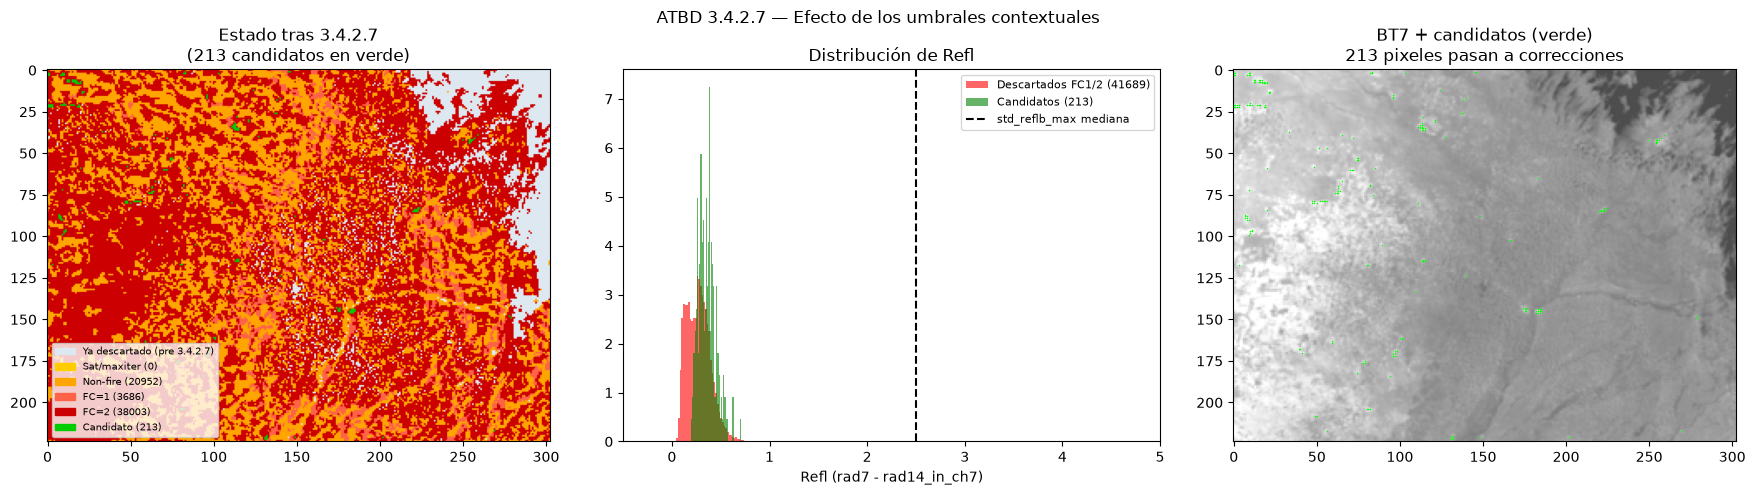

In [91]:
# ── Visualización 3.4.2.7 ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ATBD 3.4.2.7 — Efecto de los umbrales contextuales', fontsize=12)

# Panel 1: Mapa de lo que queda vs lo que se descarta
status = np.zeros((L, W), dtype=int)  # 0 = ya descartado antes
status[has_bkg & remaining] = 1       # 1 = llego a 3.4.2.7
status[test1] = 2                     # 2 = descartado sat/maxiter
status[test2] = 3                     # 3 = descartado non-fire
status[fc1] = 4                       # 4 = descartado FC=1
status[fc2] = 5                       # 5 = descartado FC=2
status[candidatos_347] = 6            # 6 = candidato real

from matplotlib.colors import ListedColormap
cmap_status = ListedColormap(['#dde8f0', '#b0c4de', '#ffcc00', '#ffa500', '#ff6347', '#cc0000', '#00cc00'])
axes[0].imshow(status, cmap=cmap_status, vmin=0, vmax=6, origin='upper')
axes[0].set_title(f'Estado tras 3.4.2.7\n({candidatos_347.sum()} candidatos en verde)')
import matplotlib.patches as mpatches
patches = [
    mpatches.Patch(color='#dde8f0', label='Ya descartado (pre 3.4.2.7)'),
    mpatches.Patch(color='#ffcc00', label=f'Sat/maxiter ({test1.sum()})'),
    mpatches.Patch(color='#ffa500', label=f'Non-fire ({test2.sum()})'),
    mpatches.Patch(color='#ff6347', label=f'FC=1 ({fc1.sum()})'),
    mpatches.Patch(color='#cc0000', label=f'FC=2 ({fc2.sum()})'),
    mpatches.Patch(color='#00cc00', label=f'Candidato ({candidatos_347.sum()})'),
]
axes[0].legend(handles=patches, loc='lower left', fontsize=7)

# Panel 2: Histograma de Refl para candidatos vs descartados
refl_cand = refl[candidatos_347 & (refl > -9998)]
refl_desc = refl[(fc1 | fc2) & (refl > -9998)]
if len(refl_cand) > 0:
    axes[1].hist(refl_desc, bins=50, alpha=0.6, color='red', label=f'Descartados FC1/2 ({len(refl_desc)})', density=True)
    axes[1].hist(refl_cand, bins=50, alpha=0.6, color='green', label=f'Candidatos ({len(refl_cand)})', density=True)
    axes[1].axvline(np.nanmedian(std_reflb_max_arr[has_bkg]), color='black', ls='--', label='std_reflb_max mediana')
    axes[1].set_xlabel('Refl (rad7 - rad14_in_ch7)')
    axes[1].set_title('Distribución de Refl')
    axes[1].legend(fontsize=8)
    axes[1].set_xlim(-0.5, 5)

# Panel 3: BT7 de candidatos sobre imagen
vbt = np.nanpercentile(inp.bt7, [2, 99])
axes[2].imshow(inp.bt7, cmap='gray', vmin=vbt[0], vmax=vbt[1], origin='upper', alpha=0.7)
ci, cj = np.where(candidatos_347)
if len(ci) > 0:
    axes[2].scatter(cj, ci, c='lime', s=5, marker='.', linewidths=0, zorder=5)
axes[2].set_title(f'BT7 + candidatos (verde)\n{candidatos_347.sum()} pixeles pasan a correcciones')

plt.tight_layout()
plt.show()

---
## ATBD 3.4.2.8: Correcciones TPW + emisividad + solar + difracción 

Sobre los `candidatos_347` (los que sobrevivieron 3.4.2.7), aplicamos en orden:

1. **TPW** (`_tpw_lut_indices` + LUT): corrige absorción atmosférica en B07/B14.
2. **Nube/humo delgado** (solo diurno, con `refl2`): si `Albedo_pixel - ABkg` cae en
   `(0.025, 0.07)` se aplica un ajuste proporcional a BT7/BT14 y se marca `FailChar=8`;
   si `Albedo_pixel > 0.38` o la diferencia es `>= 0.07`, ajuste fijo.
3. **Emisividad**: `rad / emiss`.
4. **Solar** (`_solar_correction`, solo canal 7): resta la componente de reflectancia
   solar estimada a partir del background en espacio-14 llevado a espacio-7.
5. **Difracción**: corrige contaminación óptica cruzada entre canales.

Cualquier radiancia o temperatura `<= 0` en alguna etapa se marca `FireMask.CONV_ERROR`
y el píxel se descarta (igual que en `part1.py`).

In [92]:
# Vectorizado (loop) sobre candidatos_347. Llama funciones de producción,
# no reimplementa nada: _tpw_lut_indices, _solar_correction, _background_albedo

from fdca.part1 import _tpw_lut_indices, _solar_correction, _background_albedo
from fdca.planck import planck_temp_from_coeffs, planck_rad_from_coeffs

coords_348 = np.argwhere(candidatos_347)
lut = inp.lut_tpw
print(f'Aplicando 3.4.2.8 a {len(coords_348):,} candidatos que sobrevivieron 3.4.2.7')

recs_348 = []
for i, j in coords_348:
    i, j = int(i), int(j)
    bkg = bkg_map[i, j]
    day_pixel = bool(is_day[i, j])

    # ── Captura de valores originales (pre-corrección) ─────────────────
    T7_orig  = float(inp.bt7[i, j])
    T14_orig = float(bt14_eff[i, j])
    Tb_orig  = float(bkg.temp7_bkg_mean)

    # ── TPW ─────────────────────────────────────────────────────────────
    col = _tpw_lut_indices(float(inp.tpw[i, j]), float(inp.lza[i, j]))
    trans7, trans14 = float(lut[2, col]), float(lut[3, col])
    ext7,   ext14   = float(lut[4, col]), float(lut[5, col])

    r7  = float(inp.rad7[i, j])
    r14 = float(rad14_eff[i, j])
    r7_corr  = (r7  - ext7  * r7 ) / trans7
    r14_corr = (r14 - ext14 * r14) / trans14
    if r7_corr < 0 or r14_corr < 0:
        recs_348.append({'i': i, 'j': j, 'conv_error': True, 'etapa': 'tpw'})
        continue

    T7_corr  = float(planck_temp_from_coeffs(r7_corr,  **inp.coeffs7))
    T14_corr = float(planck_temp_from_coeffs(r14_corr, **inp.coeffs14))
    if T7_corr <= 0 or T14_corr <= 0:
        recs_348.append({'i': i, 'j': j, 'conv_error': True, 'etapa': 'tpw_temp'})
        continue

    # ── Nube/humo delgado (solo diurno) ───────────────────────────────────
    alb_ij  = albedo[i, j] if inp.refl2 is not None else np.nan
    alb_bkg = _background_albedo(bkg.vis_mean_bkg, sza_cos[i, j], day_pixel)
    fc8 = False
    if day_pixel and inp.refl2 is not None and np.isfinite(alb_ij) and np.isfinite(alb_bkg):
        alb_diff = alb_ij - alb_bkg
        if CLOUD_ADJ_ALBEDO_LOW < alb_diff < CLOUD_ADJ_ALBEDO_HIGH:
            T7_corr  += CLOUD_ADJ_BT7_COEF  * alb_diff
            T14_corr += CLOUD_ADJ_BT14_COEF * alb_diff
            fc8 = True
        elif alb_ij > CLOUD_ALBEDO_THRESH or alb_diff >= CLOUD_ADJ_ALBEDO_HIGH:
            T7_corr  += CLOUD_ADJ_BT7_FIXED
            T14_corr += CLOUD_ADJ_BT14_FIXED
            fc8 = True

    # ── Emisividad ──────────────────────────────────────────────────────
    em7  = float(inp.emiss7 [i, j])
    em14 = float(inp.emiss14[i, j])
    r7_corr_em  = r7_corr  / em7
    r14_corr_em = r14_corr / em14

    # ── Background: BT -> rad -> TPW ───────────────────────────────────
    r7_bkg_raw   = planck_rad_from_coeffs(bkg.temp7_bkg_mean,  **inp.coeffs7)
    r14_bkg_raw  = planck_rad_from_coeffs(bkg.temp14_bkg_mean, **inp.coeffs14)
    r7_bkg_corr  = (r7_bkg_raw  - ext7  * r7_bkg_raw ) / trans7
    r14_bkg_corr = (r14_bkg_raw - ext14 * r14_bkg_raw) / trans14
    if r7_bkg_corr <= 0 or r14_bkg_corr <= 0:
        recs_348.append({'i': i, 'j': j, 'conv_error': True, 'etapa': 'bkg_tpw'})
        continue

    # ── Solar (canal 7) ─────────────────────────────────────────────────
    try:
        r7_solar_corr, rad7from14_bkg = _solar_correction(
            r7_corr_em, r7_bkg_corr, r14_bkg_corr, em7,
            inp.coeffs7, inp.coeffs14,
        )
    except Exception:
        recs_348.append({'i': i, 'j': j, 'conv_error': True, 'etapa': 'solar'})
        continue
    if r7_solar_corr <= 0:
        recs_348.append({'i': i, 'j': j, 'conv_error': True, 'etapa': 'solar_neg'})
        continue

    # ── Difracción ──────────────────────────────────────────────────────
    r7_diff_  = (r7_solar_corr - DIFFRAC_CH7_SUB  * rad7from14_bkg) / DIFFRAC_CH7_DIV
    r14_diff_ = (r14_corr      - DIFFRAC_CH14_SUB * r14_bkg_corr)   / DIFFRAC_CH14_DIV
    if r7_diff_ <= 0 or r14_diff_ <= 0:
        recs_348.append({'i': i, 'j': j, 'conv_error': True, 'etapa': 'difrac'})
        continue

    T7c  = float(planck_temp_from_coeffs(r7_diff_,  **inp.coeffs7))
    T14c = float(planck_temp_from_coeffs(r14_diff_, **inp.coeffs14))
    Tbc  = float(planck_temp_from_coeffs(r7_bkg_corr, **inp.coeffs7))
    if T7c <= 0 or T14c <= 0 or Tbc <= 0:
        recs_348.append({'i': i, 'j': j, 'conv_error': True, 'etapa': 'temp_final'})
        continue

    recs_348.append({
        'i': i, 'j': j, 'conv_error': False, 'etapa': None,
        'fc8_smoke': fc8,
        # Guardamos las originales para la comparación
        'T7_orig': T7_orig,   'T7c': T7c,   'dT7': T7c - T7_orig,
        'T14_orig': T14_orig, 'T14c': T14c, 'dT14': T14c - T14_orig,
        'Tb_orig': Tb_orig,   'Tbc': Tbc,   'dTb': Tbc - Tb_orig,
        'r7_diff': r7_diff_, 'r14_diff': r14_diff_,
        'r7_bkg_corr': r7_bkg_corr, 'r14_bkg_corr': r14_bkg_corr,
    })

df_348 = pd.DataFrame(recs_348)

# CONV_ERROR también actualiza fire_mask (igual que part1.py)
for _, row in df_348[df_348.conv_error].iterrows():
    fire_mask[int(row.i), int(row.j)] = FireMask.CONV_ERROR

n_err = int(df_348['conv_error'].sum())
print(f'  CONV_ERROR en alguna etapa: {n_err} ({100*n_err/len(df_348):.2f}%)')
if n_err:
    print(df_348.loc[df_348.conv_error, 'etapa'].value_counts().to_string())
print(f'  Corregidos OK: {len(df_348) - n_err}')
print(f'  Ajuste nube/humo (FC=8) aplicado en: {int(df_348["fc8_smoke"].sum())} píxeles')

# ── Resumen Comparativo ─────────────────────────────────────────────────────
cols_comparacion = [
    'T7_orig', 'T7c', 'dT7',
    'T14_orig', 'T14c', 'dT14',
    'Tb_orig', 'Tbc', 'dTb'
]

# Mostramos estadísticas descriptivas (Media, Desv. Estándar, Min, Max, etc.)
df_348.loc[~df_348.conv_error, cols_comparacion].describe().round(2)

Aplicando 3.4.2.8 a 213 candidatos que sobrevivieron 3.4.2.7
  CONV_ERROR en alguna etapa: 0 (0.00%)
  Corregidos OK: 213
  Ajuste nube/humo (FC=8) aplicado en: 182 píxeles


,T7_orig,T7c,dT7,T14_orig,T14c,dT14,Tb_orig,Tbc,dTb
count,213.00,213.00,213.00,213.00,213.00,213.00,213.00,213.00,213.00
mean,311.72,314.81,3.09,304.41,311.37,6.96,305.28,306.63,1.35
std,4.47,4.42,0.88,5.41,6.15,1.27,4.11,4.04,0.12
min,302.30,304.98,-0.30,275.44,270.75,-4.70,297.88,299.34,1.21
25%,308.07,311.14,2.64,300.93,307.96,6.61,301.73,303.22,1.26
50%,312.37,315.45,3.12,305.34,312.12,6.98,306.48,307.82,1.27
75%,315.22,317.96,3.65,308.59,315.59,7.48,308.98,310.28,1.48
max,322.53,325.58,5.45,314.97,324.10,9.37,312.82,314.12,1.57


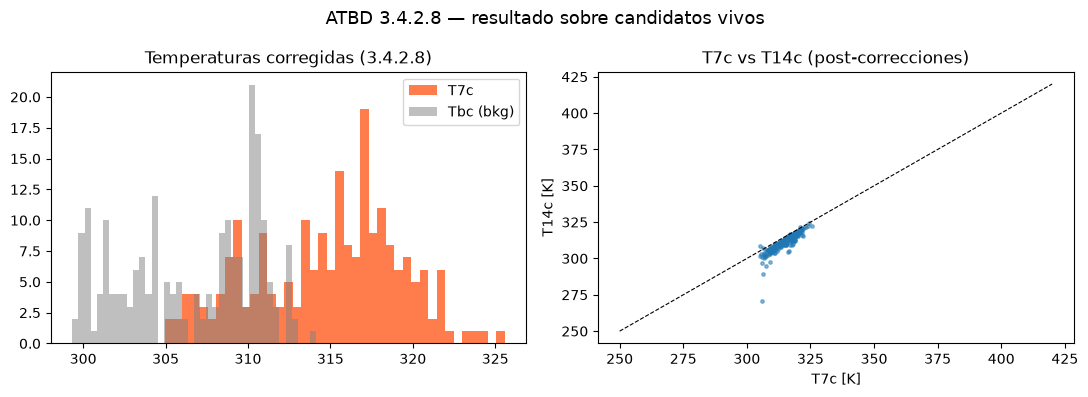

In [93]:
ok = ~df_348.conv_error
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(df_348.loc[ok, 'T7c'],  bins=40, alpha=0.7, label='T7c',  color='orangered')
axes[0].hist(df_348.loc[ok, 'Tbc'],  bins=40, alpha=0.5, label='Tbc (bkg)', color='gray')
axes[0].set_title('Temperaturas corregidas (3.4.2.8)')
axes[0].legend()

axes[1].scatter(df_348.loc[ok, 'T7c'], df_348.loc[ok, 'T14c'], s=6, alpha=0.5)
axes[1].plot([250, 420], [250, 420], 'k--', lw=0.8)
axes[1].set_xlabel('T7c [K]'); axes[1].set_ylabel('T14c [K]')
axes[1].set_title('T7c vs T14c (post-correcciones)')

plt.suptitle('ATBD 3.4.2.8 — resultado sobre candidatos vivos', fontsize=13)
plt.tight_layout()
plt.show()

Histograma Izquierdo: $T_{bc}$ (gris) debe formar un pico angosto y limpio más a la izquierda (por ejemplo, centrado en 300–304 K). $T_{7c}$ (naranja) debe estar claramente desplazado hacia la derecha, empezando recién por encima de los 320–325 K y extendiéndose hacia temperaturas más altas.Scatter Plot Derecho: El panel derecho en sí muestra la forma analítica correcta ($T_{14c}$ saturando cerca de 310 K mientras $T_{7c}$ se dispara hacia la derecha), pero la "nube" densa de la izquierda debería estar desplazada más hacia la derecha ($T_{7c} > 330\text{ K}$) y no acumulada en 310–315 K.

---
## ATBD 3.4.2.9: Post corrections tests

En este paso clasificamos los candidatos según su comportamiento térmico corregido.
Los píxeles marcados con 3, 4, 5 o 10 se saltan Dozier (skip_dozier) y van a "Last Chance".
También se evalúa el flag 8 (posible glint solar) para la confianza en Fase 2.

In [94]:
# Listas para almacenar los resultados por cada fila de df_348
fail_chars_step = []
skip_dozier = []

# Iteramos sobre los candidatos que sobrevivieron a las correcciones (3.4.2.8)
for idx, row in df_348.iterrows():
    i, j = int(row.i), int(row.j)
    
    # 1. Recuperar parámetros necesarios
    t7c, t14c, tbc = row.T7c, row.T14c, row.Tbc
    p_is_day = bool(is_day[i, j])
    p_sza_cos = sza_cos[i, j]
    p_cloudy = cloud_mask[i, j] # Calculado en 3.4.2.3
    p_albedo = albedo[i, j] if inp.refl2 is not None else 0.0
    
    # 2. Test de umbrales absolutos (FailChar 3)
    # T14c < 285K o T7c por debajo del umbral diurno/nocturno
    t7_limit = 285.0 + (15.0 * p_sza_cos if p_is_day else 0.0)
    f3 = (t14c < 285.0) or (t7c < t7_limit)
    
    # 3. Test de contraste con el fondo en B14 (FailChar 4 o 10)
    f4_10 = False
    is_f10 = False
    if (t14c - tbc) < 0.25:
        f4_10 = True
        # Bifurcación F10 (Nube/Humo) vs F4 (Diferencia mínima)
        if (p_albedo > 0.15 or p_cloudy) and (t7c - tbc > 10.0):
            is_f10 = True

    # 4. Test de contraste mínimo en B07 (FailChar 5)
    f5 = (t7c - tbc) < 2.0
    
    # --- Asignación de FailChar y skip_dozier ---
    fc = FailChar.NONE
    if f3:
        fc = FailChar.F3
    elif f4_10:
        fc = FailChar.F10 if is_f10 else FailChar.F4
    elif f5:
        fc = FailChar.F5
        
    # --- Flag 8: Potential Glint (Solo si no tiene un FC que ya lo sacó de Dozier) ---
    if p_is_day and inp.refl2 is not None and fc == FailChar.NONE:
        # Recuperamos el albedo de fondo calculado en 3.4.2.6
        p_alb_bkg = df_thresh[(df_thresh.i == i) & (df_thresh.j == j)].alb_bkg.values
        if p_albedo >= 0.25 or (p_albedo - p_alb_bkg > 0.07):
            fc = FailChar.F8

    fail_chars_step.append(fc)
    # Según ATBD, códigos 3, 4, 5 y 10 saltan Dozier
    skip_dozier.append(fc in [FailChar.F3, FailChar.F4, FailChar.F5, FailChar.F10])
    
    # Actualizar el array global de FailChar que venimos arrastrando
    fail_char[i, j] = fc

# Guardar resultados en el DataFrame para la siguiente celda (Dozier)
df_348['fail_char'] = fail_chars_step
df_348['skip_dozier'] = skip_dozier

print(f"--- Resumen 3.4.2.9 ---")
print(df_348['fail_char'].value_counts())
print(f"\nPíxeles que irán a Dozier (FC=0 u 8): {int((~df_348.skip_dozier).sum())}")
print(f"Píxeles que saltan Dozier (FC=3,4,5,10): {int(df_348.skip_dozier.sum())}")

--- Resumen 3.4.2.9 ---
fail_char
-1    169
 8     31
 4     12
 3      1
Name: count, dtype: int64

Píxeles que irán a Dozier (FC=0 u 8): 200
Píxeles que saltan Dozier (FC=3,4,5,10): 13


3: Las temperaturas corregidas son demasiado bajas (BT14c < 285 K o BT7c < umbral diurno/nocturno).

4: El contraste térmico en el canal 14 corregido es insignificante (< 0.25 K respecto al fondo).

5: El ajuste o "exceso" de temperatura en el canal 7 corregido es demasiado bajo (< 2.0 K).

8: Glint potencial: El albedo del píxel es mucho mayor que el del fondo (> 0.07 de diferencia). Se usa para dar una "segunda oportunidad" a píxeles que podrían ser reflejos solares pero resultan ser fuegos.

10: Caso de nube o humo denso: Contraste mínimo en BT14 pero con un exceso de calor muy alto en BT7 (> 10 K) en un píxel marcado como nublado.

---
## ATBD 3.4.2.10: Dozier sub-pixel

Corremos `compute_dozier` para el mismo píxel ejemplo y mostramos la solución `(fire_temp, fire_frac, FRP)`.

In [95]:
from fdca.dozier import compute_dozier, compute_pixel_area

recs_dozier = []

for _, row in df_348.loc[
    (~df_348.conv_error) &
    (~df_348.skip_dozier)
].iterrows():

    i = int(row.i)
    j = int(row.j)

    # Dozier
    is_glint = row.fail_char == FailChar.F8

    res = compute_dozier(
        rad7=row.r7_diff,
        rad14=row.r14_diff,
        rad7_bkg=row.r7_bkg_corr,
        rad14_bkg=row.r14_bkg_corr,
        Tb=row.Tbc,
        coeffs7=inp.coeffs7,
        coeffs14=inp.coeffs14,
        is_potential_glint=is_glint,
)

    # área del pixel
    pixel_area = compute_pixel_area(
        i, j,
        inp.latitudes,
        inp.longitudes,
    )

    # completar área quemada
    fire_area = np.nan
    if res.valid:
        fire_area = res.fire_frac * pixel_area


    recs_dozier.append({
        "i": i,
        "j": j,
        "valid": res.valid,
        "Tfire": res.fire_temp,
        "fire_frac": res.fire_frac,
        "fire_area": fire_area,
        "fail_char": res.fail_char,
    })

df_dozier = pd.DataFrame(recs_dozier)

# Vista general
print(f"Total píxeles procesados: {len(df_dozier)}")
print(f"Píxeles válidos: {df_dozier.valid.sum()} ({df_dozier.valid.mean()*100:.1f}%)")

# Estadísticas descriptivas solo de los válidos
display(df_dozier[df_dozier.valid].describe())

# Distribución de fail_char (útil para ver por qué fallan los inválidos)
print(df_dozier.fail_char.value_counts())


Total píxeles procesados: 200
Píxeles válidos: 11 (5.5%)


,i,j,Tfire,fire_frac,fire_area,fail_char
count,11.000000,11.000000,11.000000,11.000000,11.000000,11.0
mean,77.272727,93.454545,449.848174,0.010085,0.051572,-1.0
std,60.408759,101.919933,37.523787,0.007096,0.040723,0.0
min,21.000000,0.000000,403.340485,0.002389,0.012089,-1.0
25%,32.500000,13.500000,421.171409,0.004976,0.021573,-1.0
50%,70.000000,63.000000,448.142177,0.007484,0.035209,-1.0
75%,86.500000,160.000000,472.013595,0.014244,0.076763,-1.0
max,204.000000,255.000000,520.258710,0.024442,0.135337,-1.0


fail_char
 6    165
 9     24
-1     11
Name: count, dtype: int64


## ATBD 3.4.2.11: Last chance fire tests
Aquí intentamos recuperar candidatos que fallaron Dozier o fueron saltados.
Los píxeles recuperados tendrán área sub-píxel = 0.


In [96]:
# --- Preparación: mapas de lookup rápido (evita filtrar df_thresh/df_dozier en cada iteración) ---
thresh_map = {(r.i, r.j): r for r in df_thresh.itertuples()}
dozier_map = {(r.i, r.j): r for r in df_dozier.itertuples()}

last_chance_recovered = []

for idx, row in df_348.iterrows():
    i, j = int(row.i), int(row.j)

    doz = dozier_map.get((i, j))
    dozier_valido = bool(doz.valid) if doz is not None else False

    # Glint sospechoso: FC8 con Tfire estimada < 400K (aunque Dozier haya "convergido")
    es_glint_bajo = (
        row.fail_char == FailChar.F8
        and doz is not None
        and doz.valid
        and doz.Tfire < 400.0
    )

    # ¿Es candidato a Last Chance?
    if row.skip_dozier or not dozier_valido or es_glint_bajo:

        tr = thresh_map.get((i, j))
        if tr is None:
            continue  # sin info de threshold, no se puede evaluar

        # --- Condición A (ATBD 3.4.2.11) ---
        # Exceso de BT7 corregida >= umbral contextual Y BT14 no demasiado fría respecto al fondo
        cond_a = (row.T7c - row.Tbc >= tr.std_7b) and (row.T14c - tr.bt14_bkg >= -20.0)

        # --- Condición B (ATBD 3.4.2.11) ---
        # Exceso de reflectividad (albedo) >= umbral de desviación estándar máximo Y pasa test along-scan
        p_albedo = row.albedo if hasattr(row, 'albedo') else (albedo[i, j] if inp.refl2 is not None else 0.0)
        alb_bkg = getattr(tr, 'alb_bkg', np.nan)
        refl_diff = p_albedo - alb_bkg if not np.isnan(alb_bkg) else np.nan
        cond_b = (
            not np.isnan(refl_diff)
            and refl_diff >= tr.std_reflb_max
            and bool(tr.pass_along)
        )

        if cond_a or cond_b:
            # ¡Recuperado! Tamaño sub-píxel forzado a 0 (ATBD 3.4.2.11)
            fire_temp = -999.0

            # Lógica de smoldering (fuego latente): 350K < T7c <= 400K
            if 350.0 < row.T7c <= 400.0:
                fire_temp = -row.T7c

            fire_area = 0.0

            # --- Verificación final de área (ATBD 3.4.2.11, punto 4) ---
            mask_code = None
            if fire_area < 4.0:
                fire_area_recalc = compute_pixel_area(
                    i, j, inp.latitudes, inp.longitudes
                )
                # Nota: compute_pixel_area clampea a 0.0 en vez de dar negativo
                # (Heron con max(0.0, ...) dentro de la raíz), así que el "área
                # negativa" del ATBD se traduce acá en área == 0.0 (geometría degenerada).
                if fire_area_recalc <= 0.0:
                    mask_code = 188  # error de cálculo de área -> descartar
                else:
                    fire_area = fire_area_recalc

            if mask_code == 188:
                fire_mask[i, j] = 188
                continue  # descartado, no se agrega a recuperados

            last_chance_recovered.append({
                'i': i, 'j': j,
                'fire_temp': fire_temp,
                'fire_area': fire_area,
                'cond_a': cond_a,
                'cond_b': cond_b,
                'type': 'Recuperado (Last Chance)',
            })

            # Re-activamos el píxel en la máscara global para que Fase 2 lo evalúe
            fire_mask[i, j] = FireMask.FIRE_FREE

df_last_chance = pd.DataFrame(last_chance_recovered)

print(f"--- Resumen 3.4.2.11 ---")
print(f"Píxeles recuperados con éxito: {len(df_last_chance)}")
if not df_last_chance.empty:
    print(df_last_chance[['i', 'j', 'fire_temp', 'fire_area', 'type']].head())

--- Resumen 3.4.2.11 ---
Píxeles recuperados con éxito: 197
   i    j  fire_temp  fire_area                      type
0  1   83     -999.0   3.684186  Recuperado (Last Chance)
1  1  145     -999.0   4.009562  Recuperado (Last Chance)
2  1  146     -999.0   3.995216  Recuperado (Last Chance)
3  2    0     -999.0   2.180384  Recuperado (Last Chance)
4  2    1     -999.0   3.586261  Recuperado (Last Chance)


Entraron a Dozier: 200
Válidos (sobreviven): 11
Descartados en Dozier: 189
Candidatos evaluados en Last Chance: ver abajo
Recuperados con éxito: 197
Descartados por área degenerada (188): 0


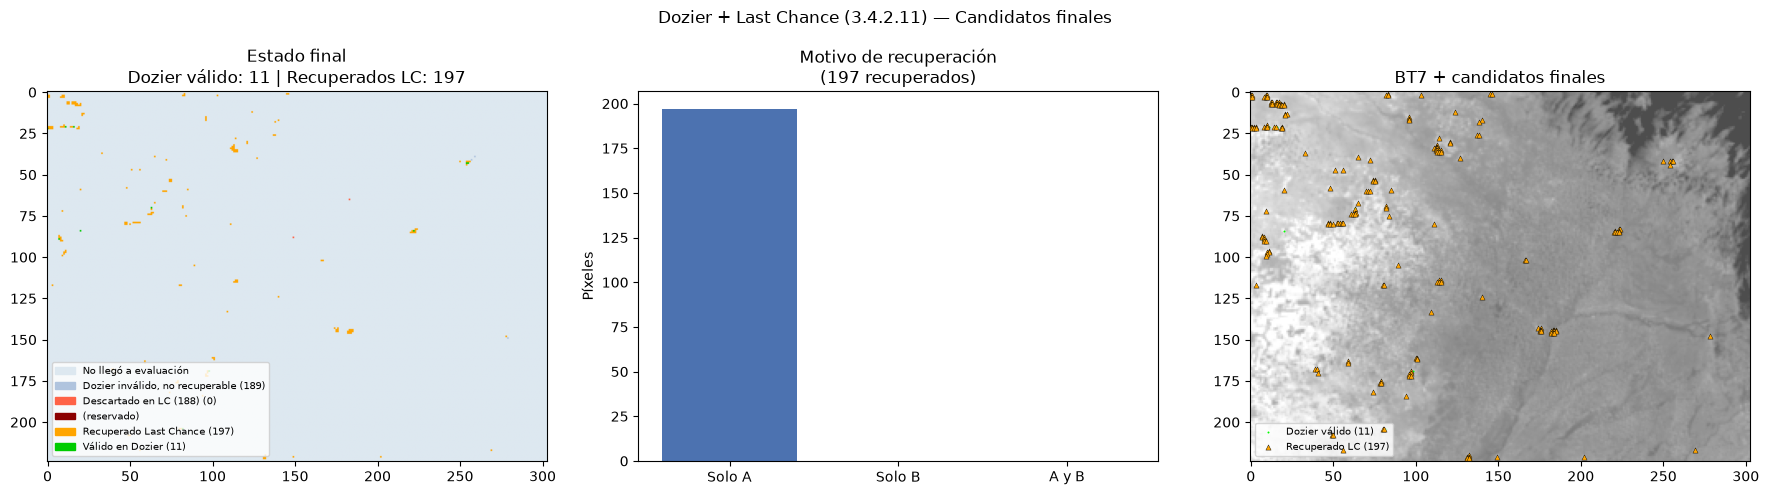

In [97]:
# ── Reconstruir grilla de candidatos que sobreviven a Dozier ───────────────
candidatos_dozier = np.zeros((L, W), dtype=bool)
ii = df_dozier.loc[df_dozier.valid, "i"].values
jj = df_dozier.loc[df_dozier.valid, "j"].values
candidatos_dozier[ii, jj] = True

descartados_dozier = np.zeros((L, W), dtype=bool)
ii_d = df_dozier.loc[~df_dozier.valid, "i"].values
jj_d = df_dozier.loc[~df_dozier.valid, "j"].values
descartados_dozier[ii_d, jj_d] = True

print(f"Entraron a Dozier: {len(df_dozier)}")
print(f"Válidos (sobreviven): {candidatos_dozier.sum()}")
print(f"Descartados en Dozier: {descartados_dozier.sum()}")
# ── Reconstruir grilla de recuperados en Last Chance ────────────────────
recuperados_lc = np.zeros((L, W), dtype=bool)
if not df_last_chance.empty:
    ii_lc = df_last_chance["i"].values
    jj_lc = df_last_chance["j"].values
    recuperados_lc[ii_lc, jj_lc] = True

# Descartados definitivamente en 3.4.2.11 (mask_code == 188)
descartados_lc = (fire_mask == 188)

print(f"Candidatos evaluados en Last Chance: {(row_mask_evaluada := (df_348.skip_dozier | ~df_348.i.map(lambda x: True))).sum() if False else 'ver abajo'}")
print(f"Recuperados con éxito: {recuperados_lc.sum()}")
print(f"Descartados por área degenerada (188): {descartados_lc.sum()}")

# ── Visualización combinada: Dozier + Last Chance ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Dozier + Last Chance (3.4.2.11) — Candidatos finales', fontsize=12)

# Panel 1: Mapa de estado combinado
status_final = np.zeros((L, W), dtype=int)
status_final[candidatos_347] = 1              # entró a evaluación (Dozier o directo a LC)
status_final[descartados_dozier] = 2          # Dozier inválido, no recuperado (todavía)
status_final[descartados_lc] = 3              # intentó LC y fue descartado (188)
status_final[recuperados_lc] = 4              # recuperado en Last Chance
status_final[candidatos_dozier] = 5           # válido directo en Dozier (sin pasar por LC)

cmap_final = ListedColormap(
    ['#dde8f0', '#b0c4de', '#ff6347', '#8b0000', '#ffa500', '#00cc00']
)
axes[0].imshow(status_final, cmap=cmap_final, vmin=0, vmax=5, origin='upper')
axes[0].set_title(
    f'Estado final\nDozier válido: {candidatos_dozier.sum()} | '
    f'Recuperados LC: {recuperados_lc.sum()}'
)

patches_final = [
    mpatches.Patch(color='#dde8f0', label='No llegó a evaluación'),
    mpatches.Patch(color='#b0c4de', label=f'Dozier inválido, no recuperable ({descartados_dozier.sum()})'),
    mpatches.Patch(color='#ff6347', label=f'Descartado en LC (188) ({descartados_lc.sum()})'),
    mpatches.Patch(color='#8b0000', label='(reservado)'),
    mpatches.Patch(color='#ffa500', label=f'Recuperado Last Chance ({recuperados_lc.sum()})'),
    mpatches.Patch(color='#00cc00', label=f'Válido en Dozier ({candidatos_dozier.sum()})'),
]
axes[0].legend(handles=patches_final, loc='lower left', fontsize=7)

# Panel 2: Condición A vs B en los recuperados
if not df_last_chance.empty:
    solo_a = (df_last_chance.cond_a & ~df_last_chance.cond_b).sum()
    solo_b = (~df_last_chance.cond_a & df_last_chance.cond_b).sum()
    ambas = (df_last_chance.cond_a & df_last_chance.cond_b).sum()
    axes[1].bar(['Solo A', 'Solo B', 'A y B'], [solo_a, solo_b, ambas], color=['#4c72b0', '#dd8452', '#55a868'])
    axes[1].set_title(f'Motivo de recuperación\n({len(df_last_chance)} recuperados)')
    axes[1].set_ylabel('Píxeles')

# Panel 3: BT7 con ambos grupos superpuestos, distinguidos por color/marcador
vbt = np.nanpercentile(inp.bt7, [2, 99])
axes[2].imshow(inp.bt7, cmap='gray', vmin=vbt[0], vmax=vbt[1], origin='upper', alpha=0.7)

ci, cj = np.where(candidatos_dozier)
axes[2].scatter(cj, ci, c='lime', s=8, marker='.', linewidths=0, zorder=5, label=f'Dozier válido ({candidatos_dozier.sum()})')

if not df_last_chance.empty:
    axes[2].scatter(
        df_last_chance['j'], df_last_chance['i'],
        c='orange', s=14, marker='^', linewidths=0.3, edgecolors='k', zorder=6,
        label=f'Recuperado LC ({len(df_last_chance)})'
    )

axes[2].set_title('BT7 + candidatos finales')
axes[2].legend(loc='lower left', fontsize=7)

plt.tight_layout()
plt.show()

## ATBD 3.4.2.12: Sub-pixel characterization: FRP

Calculamos el Fire Radiative Power (aproximación MIR, ecuación 3.4 del ATBD) para
**todos** los candidatos que llegan con una caracterización sub-píxel válida — tanto
los que convergieron en Dozier (§3.4.2.10) como los recuperados en Last Chance
(§3.4.2.11). Igual que en `part1.py`, se excluye del cálculo (FRP = -9.0 centinela)
a los píxeles saturados (FailChar=7) y a los que agotaron las iteraciones de
background (`n_passes > BKG_MAX_ITER`).

In [98]:
from fdca.dozier import compute_frp, compute_pixel_area

df_348_map = {(int(r.i), int(r.j)): r for r in df_348.itertuples()}

frp_targets = [(int(r.i), int(r.j)) for r in df_dozier[df_dozier.valid].itertuples()]
frp_targets += [(rec['i'], rec['j']) for rec in last_chance_recovered]

frp_out = []
for i, j in frp_targets:
    tr = thresh_map.get((i, j))
    row348 = df_348_map.get((i, j))
    if row348 is None:
        continue

    n_pass = tr.n_passes if tr is not None else np.nan
    es_saturado = bool(sat_flag[i, j])

    if es_saturado or (not np.isnan(n_pass) and n_pass > BKG_MAX_ITER):
        frp = -9.0
    else:
        pixel_area = compute_pixel_area(i, j, inp.latitudes, inp.longitudes)
        frp = compute_frp(pixel_area, row348.r7_diff, row348.r7_bkg_corr)

    frp_out.append({'i': i, 'j': j, 'frp': frp})

df_frp = pd.DataFrame(frp_out)
frp_map = {(r.i, r.j): r.frp for r in df_frp.itertuples()}

print(f"FRP calculado para {len(df_frp)} candidatos")
print(f"  con valor > 0  : {(df_frp.frp > 0).sum()}")
print(f"  centinela -9.0 : {(df_frp.frp == -9.0).sum()}")
display(df_frp[df_frp.frp > 0].sort_values('frp', ascending=False).head(10))

FRP calculado para 208 candidatos
  con valor > 0  : 208
  centinela -9.0 : 0


,i,j,frp
143,97,10,0.000100
170,145,183,0.000095
145,98,10,0.000083
29,6,16,0.000082
142,96,11,0.000082
171,145,184,0.000077
106,67,65,0.000077
169,145,182,0.000077
144,97,11,0.000073
174,146,183,0.000070


## ATBD 3.4.2.13: End part I

In [99]:
final_candidates = []
fire_id = 0

for idx, row in df_348.iterrows():
    i, j = int(row.i), int(row.j)

    doz = dozier_map.get((i, j))
    tr = thresh_map.get((i, j))

    if doz is not None and doz.valid:
        fire_temp, fire_frac = doz.Tfire, doz.fire_frac
        pixel_area = compute_pixel_area(i, j, inp.latitudes, inp.longitudes)
        fire_area = fire_frac * pixel_area
    else:
        lc = next((r for r in last_chance_recovered if r['i'] == i and r['j'] == j), None)
        if lc is None:
            continue
        fire_temp = lc.get('fire_temp', np.nan)
        fire_frac = 0.0
        pixel_area = compute_pixel_area(i, j, inp.latitudes, inp.longitudes)
        fire_area = 0.0

    fire_id += 1
    final_candidates.append({
        'fire_id': fire_id, 'i': i, 'j': j,
        'lat': inp.latitudes[i, j], 'lon': inp.longitudes[i, j],
        'bt7': row.T7c, 'bt14': row.T14c, 'bt7_bkg': row.Tbc,
        'r7_diff': row.r7_diff, 'r7_bkg_corr': row.r7_bkg_corr,  
        'fire_temp': fire_temp, 'fire_frac': fire_frac,
        'pixel_area': pixel_area, 'fire_area': fire_area,
        'n_passes': tr.n_passes if tr is not None else np.nan,
        'fail_char': row.fail_char, 'is_day': bool(is_day[i, j]),
        'frp': frp_map.get((i, j), np.nan),
    })

df_final = pd.DataFrame(final_candidates)
print(f"Candidatos empaquetados para Part II: {len(df_final):,}")

Candidatos empaquetados para Part II: 208


                                VALIDACIÓN PART I vs NOAA                                 
Escena:        20251117_1820
Tamaño:        224 x 303
Total píxeles: 67,872


                                 DISTRIBUCIÓN DE CÓDIGOS                                  


,Código,Nombre,NOAA,Part I,Δ,NOAA %,Part I %
0,15,LOW_PROB,6,0,-6,0.009,0.000
1,30,TEMP_PROCESSED,1,0,-1,0.001,0.000
2,100,FIRE_FREE,62154,62854,700,91.575,92.607
3,150,BAD_ECOSYSTEM,225,225,0,0.332,0.332
4,153,INLAND_WATER,852,0,-852,1.255,0.000
5,170,NO_BACKGROUND,0,10,10,0.000,0.015
6,200,CLOUD_BT14,2421,139,-2282,3.567,0.205
7,215,CLOUD_ALBEDO,2212,2869,657,3.259,4.227
8,220,CLOUD_BT15,1,1775,1774,0.001,2.615




                                         RESUMEN                                          
Coincidencia exacta : 95.21%

NOAA
  Fire     :        7
  Cloud    :    4,634
  No Fire  :   62,154
  Invalid  :    1,077

Part I
  Fire      :        0
  Candidate :        0
  Cloud     :    4,783
  No Fire   :   62,854
  Invalid   :      235

Confusion Matrix
TP :        0
FN :        7
FP :        0
TN :   67,865

Recall    : 0.00%
Precision : nan%
F1-score  : nan%


                                    TOP 20 DIFERENCIAS                                    


,NOAA,Part I,Cantidad
0,200,220,1752
1,153,100,797
2,200,215,537
3,100,215,93
4,153,215,26
5,153,220,22
6,100,170,10
7,153,200,7
8,15,100,5
9,15,215,1




                                   FALSOS NEGATIVOS (7)                                   


,row,col,NOAA,Part I,BT7,BT14
0,39,157,15,100,302.935516,291.594482
1,41,64,15,215,309.751129,294.344543
2,46,27,15,100,311.985748,296.291718
3,49,158,15,100,301.608185,289.315002
4,53,65,15,100,308.571320,297.474518
5,90,51,30,100,321.471283,308.862671
6,114,69,15,100,310.945374,296.884552


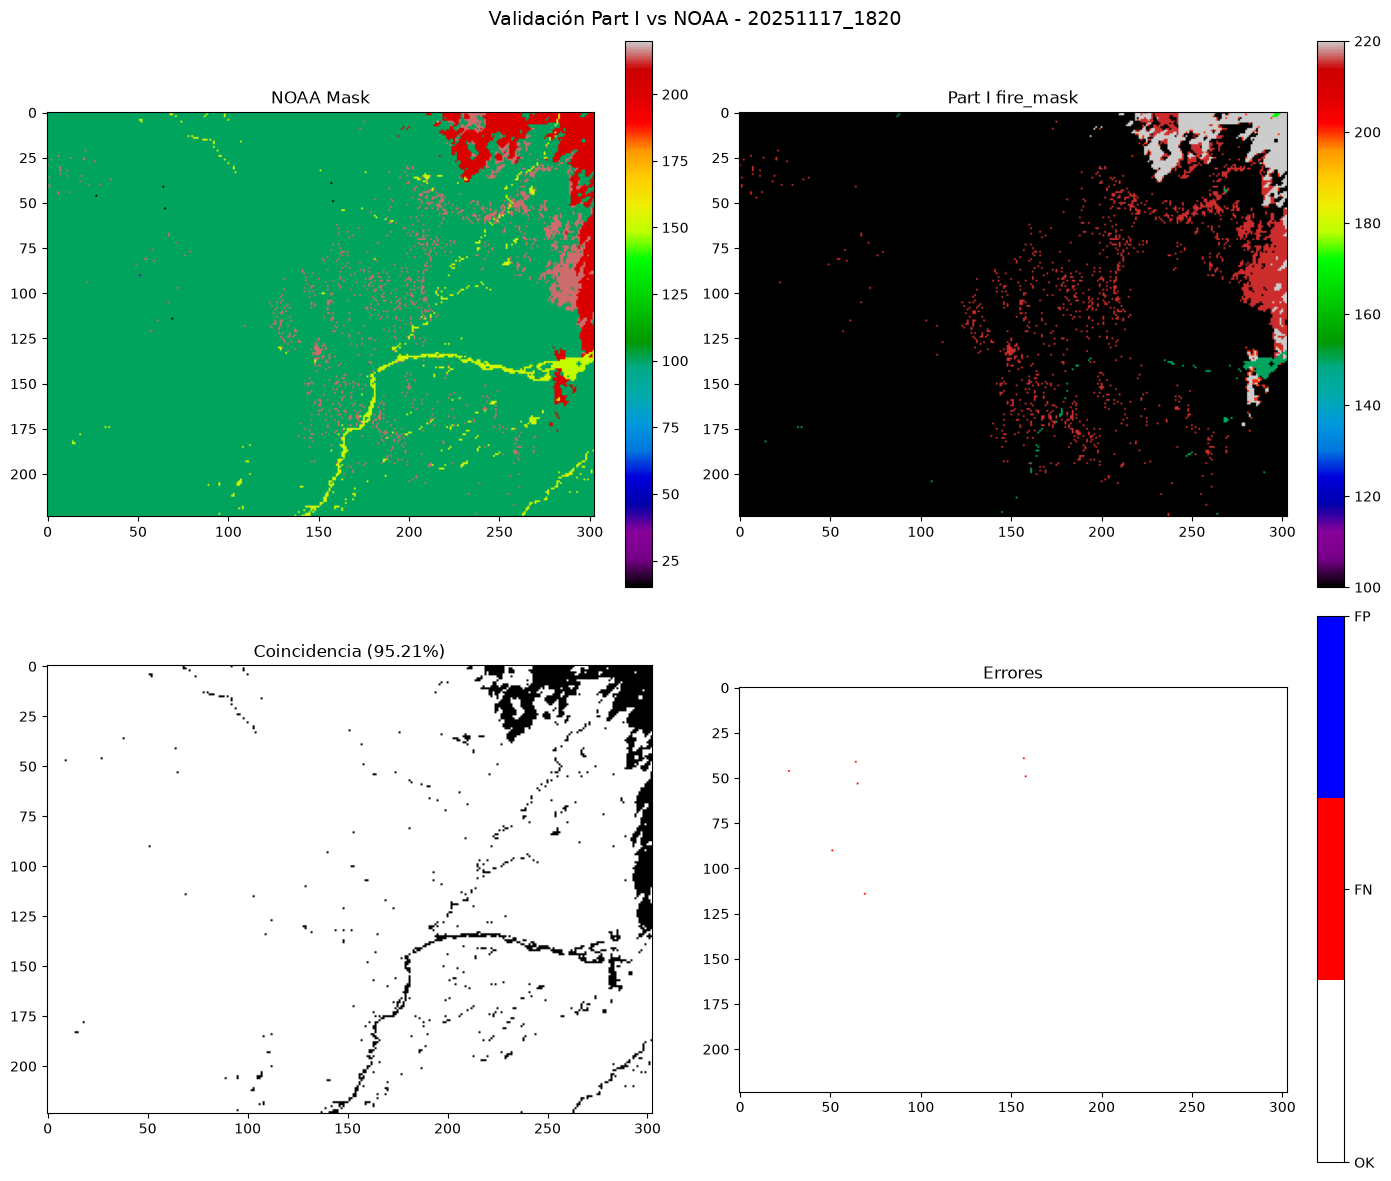

In [100]:
# ═══════════════════════════════════════════════════════════════════════════════
# VALIDACIÓN COMPLETA: Part I vs NOAA ABI-L2-FDCF Mask
# ═══════════════════════════════════════════════════════════════════════════════
# Comparción del fire_mask armado a mano contra NOAA

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

# =============================================================================
# CARGA NOAA
# =============================================================================

noaa_mask_path = Path(DATA_ROOT) / "uruguay" / "ABI-L2-FDCF-Mask" / f"{TIMESTAMP}.npy"
assert noaa_mask_path.exists()

noaa_raw = np.load(noaa_mask_path)
noaa_mask = noaa_raw.astype(np.uint8).astype(np.int32)

fm_names = {
    v: k
    for k, v in vars(FireMask).items()
    if not k.startswith("_") and isinstance(v, int)
}

print("="*90)
print("VALIDACIÓN PART I vs NOAA".center(90))
print("="*90)
print(f"Escena:        {TIMESTAMP}")
print(f"Tamaño:        {fire_mask.shape[0]} x {fire_mask.shape[1]}")
print(f"Total píxeles: {fire_mask.size:,}")

# =============================================================================
# DISTRIBUCIÓN DE CÓDIGOS
# =============================================================================

noaa_vals, noaa_counts = np.unique(noaa_mask, return_counts=True)
our_vals, our_counts = np.unique(fire_mask, return_counts=True)

rows = []

for code in sorted(set(noaa_vals) | set(our_vals)):

    n_noaa = int(noaa_counts[noaa_vals == code][0]) if code in noaa_vals else 0
    n_ours = int(our_counts[our_vals == code][0]) if code in our_vals else 0

    rows.append({
        "Código": code,
        "Nombre": fm_names.get(code, str(code)),
        "NOAA": n_noaa,
        "Part I": n_ours,
        "Δ": n_ours - n_noaa,
        "NOAA %": 100*n_noaa/fire_mask.size,
        "Part I %": 100*n_ours/fire_mask.size,
    })

df_comp = pd.DataFrame(rows)

print("\n")
print("="*90)
print("DISTRIBUCIÓN DE CÓDIGOS".center(90))
print("="*90)

display(df_comp.style.format({
    "NOAA %":"{:.3f}",
    "Part I %":"{:.3f}",
}))

# =============================================================================
# CATEGORÍAS
# =============================================================================

def categorize(mask):

    fire = np.isin(mask,[10,11,12,13,14,15,30,31,32,33,34,35])

    if hasattr(FireMask,"TOO_COLD"):
        nofire = np.isin(mask,[100,FireMask.TOO_COLD])
    else:
        nofire = mask==100

    cloud = (mask>=200)&(mask<=245)

    candidate = mask==-99

    invalid = ~(fire | nofire | cloud | candidate)

    return fire,nofire,cloud,invalid,candidate

noaa_fire,noaa_nofire,noaa_cloud,noaa_invalid,_ = categorize(noaa_mask)
our_fire,our_nofire,our_cloud,our_invalid,our_candidate = categorize(fire_mask)

our_fire_or_candidate = our_fire | our_candidate

# =============================================================================
# MÉTRICAS
# =============================================================================

TP = np.sum(noaa_fire & our_fire_or_candidate)
FN = np.sum(noaa_fire & ~our_fire_or_candidate)
FP = np.sum(~noaa_fire & our_fire)
TN = np.sum(~noaa_fire & ~our_fire_or_candidate)

precision = TP/(TP+FP) if TP+FP else np.nan
recall    = TP/(TP+FN) if TP+FN else np.nan
f1         = 2*precision*recall/(precision+recall) if precision+recall else np.nan

match = fire_mask==noaa_mask
pct_match = 100*match.mean()

print("\n")
print("="*90)
print("RESUMEN".center(90))
print("="*90)

print(f"Coincidencia exacta : {pct_match:.2f}%")
print()

print("NOAA")
print(f"  Fire     : {noaa_fire.sum():8,d}")
print(f"  Cloud    : {noaa_cloud.sum():8,d}")
print(f"  No Fire  : {noaa_nofire.sum():8,d}")
print(f"  Invalid  : {noaa_invalid.sum():8,d}")

print()

print("Part I")
print(f"  Fire      : {our_fire.sum():8,d}")
print(f"  Candidate : {our_candidate.sum():8,d}")
print(f"  Cloud     : {our_cloud.sum():8,d}")
print(f"  No Fire   : {our_nofire.sum():8,d}")
print(f"  Invalid   : {our_invalid.sum():8,d}")

print()

print("Confusion Matrix")
print(f"TP : {TP:8,d}")
print(f"FN : {FN:8,d}")
print(f"FP : {FP:8,d}")
print(f"TN : {TN:8,d}")

print()

print(f"Recall    : {100*recall:.2f}%")
print(f"Precision : {100*precision:.2f}%")
print(f"F1-score  : {100*f1:.2f}%")

# =============================================================================
# PRINCIPALES DIFERENCIAS
# =============================================================================

diff_df = pd.DataFrame({
    "NOAA":noaa_mask[~match],
    "Part I":fire_mask[~match]
})

print("\n")
print("="*90)
print("TOP 20 DIFERENCIAS".center(90))
print("="*90)

display(
    diff_df.value_counts()
    .rename("Cantidad")
    .reset_index()
    .head(20)
)

# =============================================================================
# FALSOS NEGATIVOS
# =============================================================================

fn = np.argwhere(noaa_fire & ~our_fire_or_candidate)

if len(fn):

    fn_df = pd.DataFrame(fn,columns=["row","col"])

    fn_df["NOAA"] = noaa_mask[fn[:,0],fn[:,1]]
    fn_df["Part I"] = fire_mask[fn[:,0],fn[:,1]]
    fn_df["BT7"] = inp.bt7[fn[:,0],fn[:,1]]
    fn_df["BT14"] = bt14_eff[fn[:,0],fn[:,1]]

    print("\n")
    print("="*90)
    print(f"FALSOS NEGATIVOS ({len(fn_df)})".center(90))
    print("="*90)

    display(fn_df.head(30))

# =============================================================================
# MAPAS
# =============================================================================

error = np.zeros_like(fire_mask)

error[noaa_fire & ~our_fire_or_candidate] = 1
error[~noaa_fire & our_fire] = 2

cmap = mcolors.ListedColormap(["white","red","blue"])

fig,ax = plt.subplots(2,2,figsize=(14,12))

im=ax[0,0].imshow(noaa_mask,cmap="nipy_spectral",origin="upper")
ax[0,0].set_title("NOAA Mask")
plt.colorbar(im,ax=ax[0,0],fraction=0.046)

im=ax[0,1].imshow(fire_mask,cmap="nipy_spectral",origin="upper")
ax[0,1].set_title("Part I fire_mask")
plt.colorbar(im,ax=ax[0,1],fraction=0.046)

im=ax[1,0].imshow(match,cmap="gray",origin="upper")
ax[1,0].set_title(f"Coincidencia ({pct_match:.2f}%)")

im=ax[1,1].imshow(error,cmap=cmap,vmin=0,vmax=2,origin="upper")
ax[1,1].set_title("Errores")
cbar=plt.colorbar(im,ax=ax[1,1],ticks=[0,1,2],fraction=0.046)
cbar.ax.set_yticklabels(["OK","FN","FP"])

plt.suptitle(f"Validación Part I vs NOAA - {TIMESTAMP}",fontsize=14)

plt.tight_layout()
plt.show()

---
## Correr `run_part1` completo y analizar resultados

In [101]:
import numpy as np
eco_mask = np.load("/Users/valentinachagas/Documents/GitHub/GERIS-PFC/implementacion/mask_example.npy")   # o la ruta que corresponda

In [ ]:
import time

# Obtener LUT y FPT desde el input
lut_tpw = getattr(inp, 'lut_tpw', np.ones((6, 35)))  # fallback si no existe
FPT     = getattr(inp, 'FPT', 0.0) or 0.0

t0 = time.time()
fire_mask_p1, fail_char_p1, candidates = run_part1(
    bt7=inp.bt7, rad7=inp.rad7,
    bt14=inp.bt14, rad14=inp.rad14,
    bt13=inp.bt13, rad13=inp.rad13,
    bt15=inp.bt15,
    refl2=inp.refl2,
    latitudes=inp.latitudes, longitudes=inp.longitudes,
    sza=inp.sza, glint_angle=inp.glint_angle,
    lza=inp.lza, azimuth=inp.azimuth,
    tpw=inp.tpw,
    emiss7=inp.emiss7, emiss14=inp.emiss14,
    lut_tpw=lut_tpw, FPT=FPT,
    coeffs7=inp.coeffs7, coeffs14=inp.coeffs14, coeffs13=inp.coeffs13,
    land_mask=inp.land_mask,
    eco_mask=eco_mask,
    data_quality=getattr(inp, 'data_quality', None),
)
elapsed = time.time() - t0

print(f'Part I completada en {elapsed:.1f} s')
print(f'Candidatos generados: {len(candidates):,}')

Part I completada en 165.0 s
Candidatos generados: 213


In [103]:
# ═══════════════════════════════════════════════════════════════════════════════
# VALIDACIÓN COMPLETA: Part I vs NOAA ABI-L2-FDCF Mask
# ═══════════════════════════════════════════════════════════════════════════════
# Comparción del fire_mask armado a mano contra NOAA

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

# =============================================================================
# CARGA NOAA
# =============================================================================

noaa_mask_path = Path(DATA_ROOT) / "uruguay" / "ABI-L2-FDCF-Mask" / f"{TIMESTAMP}.npy"
assert noaa_mask_path.exists()

noaa_raw = np.load(noaa_mask_path)
noaa_mask = noaa_raw.astype(np.uint8).astype(np.int32)

fm_names = {
    v: k
    for k, v in vars(FireMask).items()
    if not k.startswith("_") and isinstance(v, int)
}

print("="*90)
print("VALIDACIÓN PART I vs NOAA".center(90))
print("="*90)
print(f"Escena:        {TIMESTAMP}")
print(f"Tamaño:        {fire_mask_p1.shape[0]} x {fire_mask_p1.shape[1]}")
print(f"Total píxeles: {fire_mask.size:,}")

# =============================================================================
# DISTRIBUCIÓN DE CÓDIGOS
# =============================================================================

noaa_vals, noaa_counts = np.unique(noaa_mask, return_counts=True)
our_vals, our_counts = np.unique(fire_mask_p1, return_counts=True)

rows = []

for code in sorted(set(noaa_vals) | set(our_vals)):

    n_noaa = int(noaa_counts[noaa_vals == code][0]) if code in noaa_vals else 0
    n_ours = int(our_counts[our_vals == code][0]) if code in our_vals else 0

    rows.append({
        "Código": code,
        "Nombre": fm_names.get(code, str(code)),
        "NOAA": n_noaa,
        "Part I": n_ours,
        "Δ": n_ours - n_noaa,
        "NOAA %": 100*n_noaa/fire_mask.size,
        "Part I %": 100*n_ours/fire_mask.size,
    })

df_comp = pd.DataFrame(rows)

print("\n")
print("="*90)
print("DISTRIBUCIÓN DE CÓDIGOS".center(90))
print("="*90)

display(df_comp.style.format({
    "NOAA %":"{:.3f}",
    "Part I %":"{:.3f}",
}))




                                VALIDACIÓN PART I vs NOAA                                 
Escena:        20251117_1820
Tamaño:        224 x 303
Total píxeles: 67,872


                                 DISTRIBUCIÓN DE CÓDIGOS                                  


,Código,Nombre,NOAA,Part I,Δ,NOAA %,Part I %
0,15,LOW_PROB,6,0,-6,0.009,0.000
1,30,TEMP_PROCESSED,1,0,-1,0.001,0.000
2,100,FIRE_FREE,62154,62057,-97,91.575,91.432
3,150,BAD_ECOSYSTEM,225,225,0,0.332,0.332
4,153,INLAND_WATER,852,852,0,1.255,1.255
5,170,NO_BACKGROUND,0,224,224,0.000,0.330
6,200,CLOUD_BT14,2421,2207,-214,3.567,3.252
7,215,CLOUD_ALBEDO,2212,2306,94,3.259,3.398
8,220,CLOUD_BT15,1,1,0,0.001,0.001


In [104]:
missed = (noaa_mask == 215) & (fire_mask_p1 != FireMask.CLOUD_ALBEDO)
i_miss, j_miss = np.where(missed)
df_missed = pd.DataFrame({
    'i': i_miss, 'j': j_miss,
    'albedo': albedo[i_miss, j_miss],
    'sza': inp.sza[i_miss, j_miss],
    'bt7': inp.bt7[i_miss, j_miss],
})
print(df_missed.sort_values('albedo', ascending=False))

Empty DataFrame
Columns: [i, j, albedo, sza, bt7]
Index: []


In [105]:
missed = (noaa_mask == 215) & (fire_mask_p1 != FireMask.CLOUD_ALBEDO)
i_miss, j_miss = np.where(missed)
df_missed = pd.DataFrame({
    'i': i_miss, 'j': j_miss,
    'fire_mask_p1': fire_mask_p1[i_miss, j_miss],   # <-- the missing piece
    'albedo': albedo[i_miss, j_miss],
    'sza': inp.sza[i_miss, j_miss],
    'bt7': inp.bt7[i_miss, j_miss],
    'bt14': bt14_eff[i_miss, j_miss],
})
print(df_missed.sort_values('albedo', ascending=False).to_string())

Empty DataFrame
Columns: [i, j, fire_mask_p1, albedo, sza, bt7, bt14]
Index: []


In [106]:
ours_215 = fire_mask_p1 == FireMask.CLOUD_ALBEDO
noaa_215 = noaa_mask == FireMask.CLOUD_ALBEDO

ours_245 = fire_mask_p1 == FireMask.ALONG_SCAN_DAY
noaa_245 = noaa_mask == FireMask.ALONG_SCAN_DAY

print("215 solo nosotros:", np.sum(ours_215 & ~noaa_215))
print("215 solo NOAA:", np.sum(noaa_215 & ~ours_215))
print("245 solo nosotros:", np.sum(ours_245 & ~noaa_245))

coords_245 = np.argwhere(ours_245 & ~noaa_245)
pd.DataFrame({
    "i": coords_245[:, 0],
    "j": coords_245[:, 1],
    "albedo": albedo[ours_245 & ~noaa_245],
    "bt7": inp.bt7[ours_245 & ~noaa_245],
})

215 solo nosotros: 94
215 solo NOAA: 0
245 solo nosotros: 0


,i,j,albedo,bt7


In [107]:
# ── fire_mask_p1 (producción) vs NOAA ────────────────────────────────────
match_p1 = fire_mask_p1 == noaa_mask
print(f"Coincidencia exacta (producción vs NOAA): {100*match_p1.mean():.2f}%")

fire_p1, nofire_p1, cloud_p1, invalid_p1, cand_p1 = categorize(fire_mask_p1)
fire_or_cand_p1 = fire_p1 | cand_p1

TP_p1 = np.sum(noaa_fire & fire_or_cand_p1)
FN_p1 = np.sum(noaa_fire & ~fire_or_cand_p1)
FP_p1 = np.sum(~noaa_fire & fire_p1)
prec_p1 = TP_p1/(TP_p1+FP_p1) if TP_p1+FP_p1 else np.nan
rec_p1  = TP_p1/(TP_p1+FN_p1) if TP_p1+FN_p1 else np.nan
print(f"Precision: {100*prec_p1:.2f}%  |  Recall: {100*rec_p1:.2f}%")

# ── fire_mask (walkthrough manual) vs NOAA ─────────
match_manual_vs_noaa = fire_mask == noaa_mask
print(f"\nCoincidencia exacta (walkthrough manual vs noaa): {100*match_manual_vs_noaa.mean():.2f}%")

if not match_manual_vs_noaa.all():
    diff_mp1 = pd.DataFrame({
        "manual": fire_mask[~match_manual_vs_noaa],
        "produccion": fire_mask_p1[~match_manual_vs_noaa],
    })
    print("\nTop diferencias manual vs producción:")
    display(diff_mp1.value_counts().rename("Cantidad").reset_index().head(20))

Coincidencia exacta (producción vs NOAA): 99.52%
Precision: nan%  |  Recall: 0.00%

Coincidencia exacta (walkthrough manual vs noaa): 95.21%

Top diferencias manual vs producción:


,manual,produccion,Cantidad
0,220,200,1541
1,100,153,797
2,215,200,537
3,220,170,211
4,215,215,94
5,215,153,26
6,220,153,22
7,170,170,10
8,200,153,7
9,100,100,6


In [108]:
manual_candidates = fire_mask == FireMask.FIRE_FREE
prod_candidates = fire_mask_p1 == FireMask.FIRE_FREE

print("Manual:", manual_candidates.sum())
print("Producción:", prod_candidates.sum())
print("Solo manual:", (manual_candidates & ~prod_candidates).sum())
print("Solo producción:", (prod_candidates & ~manual_candidates).sum())
print("En ambos:", (manual_candidates & prod_candidates).sum())
print("Diferencias:", np.sum(manual_candidates != prod_candidates))

Manual: 62854
Producción: 62057
Solo manual: 797
Solo producción: 0
En ambos: 62057
Diferencias: 797


In [109]:
# ── Diagnóstico correcto: candidatos Part I vs fuego NOAA ─────────────────
# Part I deja los candidatos con máscara 100; los códigos 10-15 aparecen recién en Part II.
noaa_fire_codes = [10, 11, 12, 13, 14, 15, 30, 31, 32, 33, 34, 35]
noaa_fire = np.isin(noaa_mask, noaa_fire_codes)

p1_candidates = fire_mask_p1 == FireMask.FIRE_FREE
manual_candidates = fire_mask == FireMask.FIRE_FREE

# Comparación de detección, no igualdad de códigos entre etapas distintas.
for name, candidate_mask in [
    ("Part I producción", p1_candidates),
    ("Walkthrough manual", manual_candidates),
]:
    tp = int((candidate_mask & noaa_fire).sum())
    fp = int((candidate_mask & ~noaa_fire).sum())
    fn = int((~candidate_mask & noaa_fire).sum())
    precision = tp / (tp + fp) if tp + fp else np.nan
    recall = tp / (tp + fn) if tp + fn else np.nan
    print(f"\n{name}")
    print(f"  Candidatos: {int(candidate_mask.sum()):,}")
    print(f"  NOAA fire dentro de candidatos (TP): {tp:,}")
    print(f"  Candidatos fuera de NOAA fire (FP): {fp:,}")
    print(f"  Fuegos NOAA no cubiertos (FN): {fn:,}")
    print(f"  Precision de candidatos: {100 * precision:.2f}%")
    print(f"  Recall de NOAA fire:      {100 * recall:.2f}%")

print("\nDistribución NOAA solo en códigos de fuego:")
print(pd.Series(noaa_mask[noaa_fire]).value_counts().sort_index().to_string())


Part I producción
  Candidatos: 62,057
  NOAA fire dentro de candidatos (TP): 6
  Candidatos fuera de NOAA fire (FP): 62,051
  Fuegos NOAA no cubiertos (FN): 1
  Precision de candidatos: 0.01%
  Recall de NOAA fire:      85.71%

Walkthrough manual
  Candidatos: 62,854
  NOAA fire dentro de candidatos (TP): 6
  Candidatos fuera de NOAA fire (FP): 62,848
  Fuegos NOAA no cubiertos (FN): 1
  Precision de candidatos: 0.01%
  Recall de NOAA fire:      85.71%

Distribución NOAA solo en códigos de fuego:
15    6
30    1


---
## Diagnóstico de candidatos (producción)

In [110]:
# ── Tabla resumen de candidatos ─────────────────────────────────────────────
df_cand = pd.DataFrame([{
    'fire_id'   : c.fire_id,
    'lat'       : round(c.lat, 3),
    'lon'       : round(c.lon, 3),
    'bt7 [K]'   : round(c.bt7, 2),
    'bt14 [K]'  : round(c.bt14, 2),
    'bt7_bkg [K]': round(c.bt7_bkg, 2),
    'fire_temp [K]': round(c.fire_temp, 1) if not np.isnan(c.fire_temp) else np.nan,
    'fire_frac' : round(c.fire_frac, 6),
    'frp [MW]'  : round(c.frp, 3),
    'fail_char' : c.fail_char,
    'is_day'    : c.is_day,
} for c in candidates])

print(f'Primeros 20 candidatos (de {len(df_cand):,} total):')
print(df_cand.head(20).to_string(index=False))

Primeros 20 candidatos (de 213 total):
 fire_id     lat     lon  bt7 [K]  bt14 [K]  bt7_bkg [K]  fire_temp [K]  fire_frac  frp [MW]  fail_char  is_day
       1 -24.337 -61.446   312.51    306.66       307.77         -354.2        0.0       0.0          9    True
       2 -24.361 -60.135   307.41    302.24       301.61         -999.0        0.0       0.0          6    True
       3 -24.362 -60.114   306.53    301.53       301.73         -999.0        0.0       0.0          6    True
       4 -24.330 -63.180   316.76    311.40       309.74         -999.0        0.0       0.0          9    True
       5 -24.331 -63.159   315.57    310.42       309.56         -999.0        0.0       0.0          9    True
       6 -24.333 -62.992   314.64    309.43       309.25         -999.0        0.0       0.0          9    True
       7 -24.333 -62.971   313.87    308.46       309.38         -999.0        0.0       0.0          9    True
       8 -24.358 -61.464   312.01    307.07       307.76         

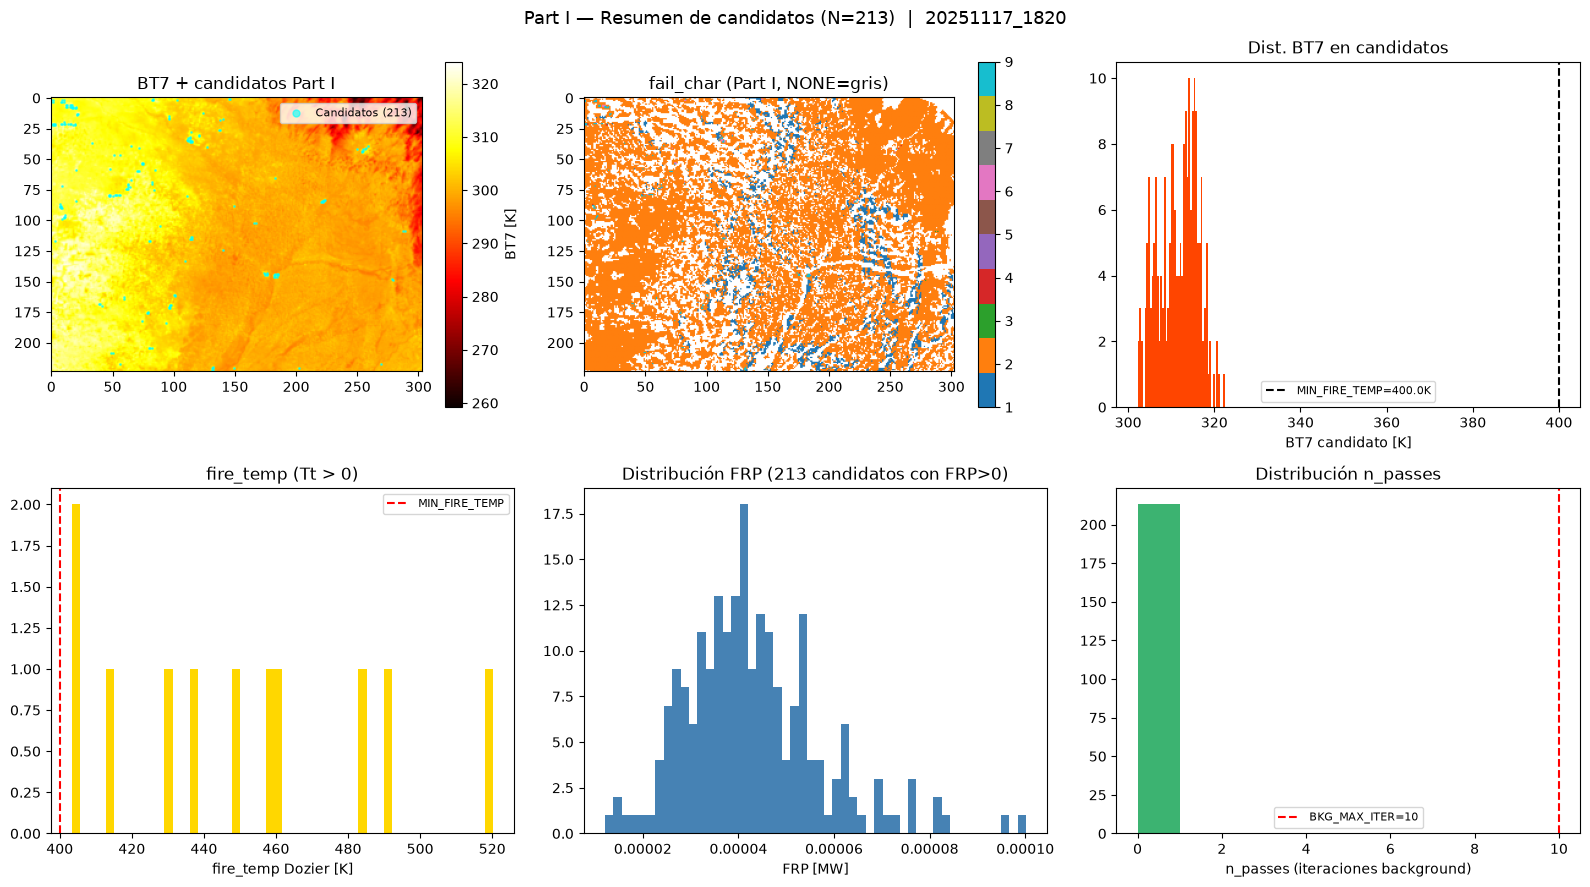

In [111]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# 1) BT7 con candidatos marcados
ax = axes[0, 0]
im = ax.imshow(inp.bt7, cmap='hot', origin='upper')
plt.colorbar(im, ax=ax, label='BT7 [K]')
if candidates:
    ci = [c.i for c in candidates]
    cj = [c.j for c in candidates]
    ax.scatter(cj, ci, s=1, c='cyan', alpha=0.6, label=f'Candidatos ({len(candidates)})')
ax.set_title('BT7 + candidatos Part I')
ax.legend(markerscale=5, fontsize=8)

# 2) fail_char map
ax = axes[0, 1]
fc_display = np.where(fail_char_p1 == FailChar.NONE, np.nan, fail_char_p1.astype(float))
im = ax.imshow(fc_display, cmap='tab10', origin='upper')
plt.colorbar(im, ax=ax)
ax.set_title('fail_char (Part I, NONE=gris)')

# 3) Distribución BT7 candidatos
ax = axes[0, 2]
if candidates:
    ax.hist([c.bt7 for c in candidates], bins=50, color='orangered', edgecolor='none')
    ax.axvline(MIN_FIRE_TEMP, color='k', linestyle='--', label=f'MIN_FIRE_TEMP={MIN_FIRE_TEMP}K')
ax.set_xlabel('BT7 candidato [K]')
ax.set_title('Dist. BT7 en candidatos')
ax.legend(fontsize=8)

# 4) fire_temp de Dozier (sólo válidos)
ax = axes[1, 0]
fire_temps = [c.fire_temp for c in candidates if c.fire_temp and c.fire_temp > 0]
if fire_temps:
    ax.hist(fire_temps, bins=50, color='gold', edgecolor='none')
    ax.axvline(MIN_FIRE_TEMP, color='r', linestyle='--', label=f'MIN_FIRE_TEMP')
ax.set_xlabel('fire_temp Dozier [K]')
ax.set_title('fire_temp (Tt > 0)')
ax.legend(fontsize=8)

# 5) FRP
ax = axes[1, 1]
frps = [c.frp for c in candidates if c.frp and c.frp > 0]
if frps:
    ax.hist(frps, bins=50, color='steelblue', edgecolor='none')
ax.set_xlabel('FRP [MW]')
ax.set_title(f'Distribución FRP ({len(frps)} candidatos con FRP>0)')

# 6) n_passes
ax = axes[1, 2]
npasses = [c.n_passes for c in candidates]
if npasses:
    ax.hist(npasses, bins=range(0, max(npasses)+2), color='mediumseagreen', edgecolor='none')
    ax.axvline(BKG_MAX_ITER, color='r', linestyle='--', label=f'BKG_MAX_ITER={BKG_MAX_ITER}')
ax.set_xlabel('n_passes (iteraciones background)')
ax.set_title('Distribución n_passes')
ax.legend(fontsize=8)

plt.suptitle(f'Part I — Resumen de candidatos (N={len(candidates):,})  |  {TIMESTAMP}', fontsize=13)
plt.tight_layout()
plt.show()

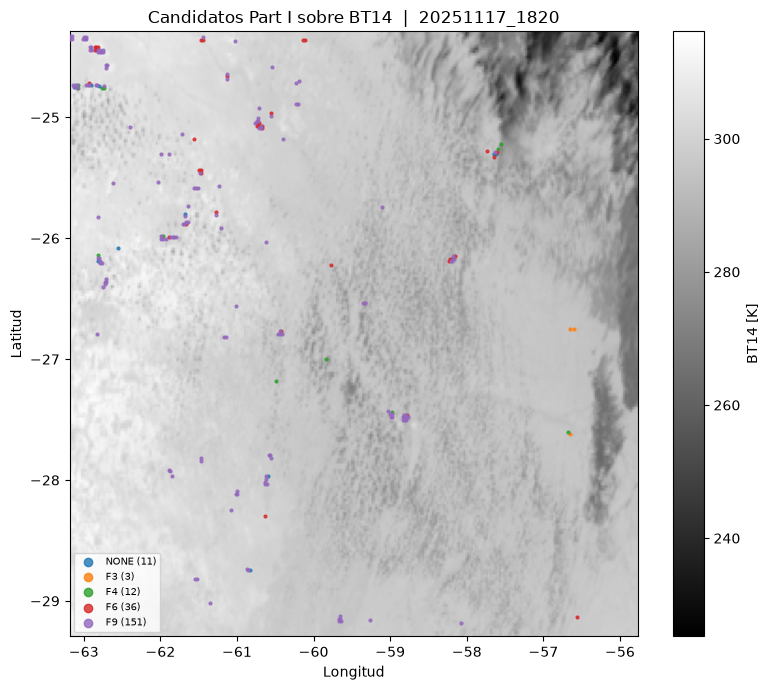

In [112]:
fig, ax = plt.subplots(figsize=(8, 7))

# BT14 como fondo
im = ax.imshow(
    bt14_eff,
    cmap='gray', origin='upper',
    extent=[inp.longitudes.min(), inp.longitudes.max(),
            inp.latitudes.min(),  inp.latitudes.max()],
    aspect='auto',
)
plt.colorbar(im, ax=ax, label='BT14 [K]')
# Necesario para el label de cada fail_char en la leyenda del scatter
fc_names = {v: k for k, v in vars(FailChar).items() if not k.startswith('_')}
# Candidatos por fail_char
fc_groups = {}
for c in candidates:
    fc = c.fail_char
    fc_groups.setdefault(fc, []).append((c.lon, c.lat))

colors_fc = plt.cm.tab10.colors
for idx, (fc, pts) in enumerate(sorted(fc_groups.items())):
    lons, lats = zip(*pts)
    label = fc_names.get(fc, str(fc))
    ax.scatter(lons, lats, s=4, color=colors_fc[idx % 10],
               alpha=0.8, label=f'{label} ({len(pts)})', zorder=5)

ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.set_title(f'Candidatos Part I sobre BT14  |  {TIMESTAMP}')
ax.legend(fontsize=7, markerscale=3, loc='lower left')
plt.tight_layout()
plt.show()

---
## Análisis de valores únicos en `fire_mask_p1` (diagnóstico §9.3)

In [113]:
# ── Resumen cuantitativo de fail_char ──────────────────────────────────────
vals, counts = np.unique(fail_char_p1[fail_char_p1 != FailChar.NONE], return_counts=True)
fc_names = {v: k for k, v in vars(FailChar).items() if not k.startswith('_') and isinstance(v, int)}

df_fc = pd.DataFrame({
    'fail_char'  : vals,
    'nombre'     : [fc_names.get(v, str(v)) for v in vals],
    'N píxeles'  : counts,
    '% candidatos': (counts / len(candidates) * 100).round(2) if len(candidates) > 0 else 0,
})
print('Distribución de fail_char entre candidatos de Part I:')
print(df_fc.to_string(index=False))


Distribución de fail_char entre candidatos de Part I:
 fail_char nombre  N píxeles  % candidatos
         1     F1       3537       1660.56
         2     F2      41657      19557.28
         3     F3          3          1.41
         4     F4         12          5.63
         6     F6         36         16.90
         9     F9        151         70.89


In [114]:
vals, counts = np.unique(fire_mask_p1, return_counts=True)
fm_names = {v: k for k, v in vars(FireMask).items() if not k.startswith('_') and isinstance(v, int)}

df_fm = pd.DataFrame({
    'fire_mask_val': vals,
    'nombre'       : [fm_names.get(v, str(v)) for v in vals],
    'N píxeles'    : counts,
    '% total'      : (counts / (L * W) * 100).round(3),
})
print('Distribución de valores en fire_mask_p1:')
print(df_fm.to_string(index=False))

# Verificación: ¿hay valores en rango 30-35 (temporales) en Part I? (no debería)
temporal_in_p1 = int(np.isin(fire_mask_p1, [30,31,32,33,34,35]).sum())
print(f'\nPíxeles 30-35 en fire_mask_p1 (debería ser 0): {temporal_in_p1}')

Distribución de valores en fire_mask_p1:
 fire_mask_val        nombre  N píxeles  % total
           100     FIRE_FREE      62057   91.432
           150 BAD_ECOSYSTEM        225    0.332
           153  INLAND_WATER        852    1.255
           170 NO_BACKGROUND        224    0.330
           200    CLOUD_BT14       2207    3.252
           215  CLOUD_ALBEDO       2306    3.398
           220    CLOUD_BT15          1    0.001

Píxeles 30-35 en fire_mask_p1 (debería ser 0): 0


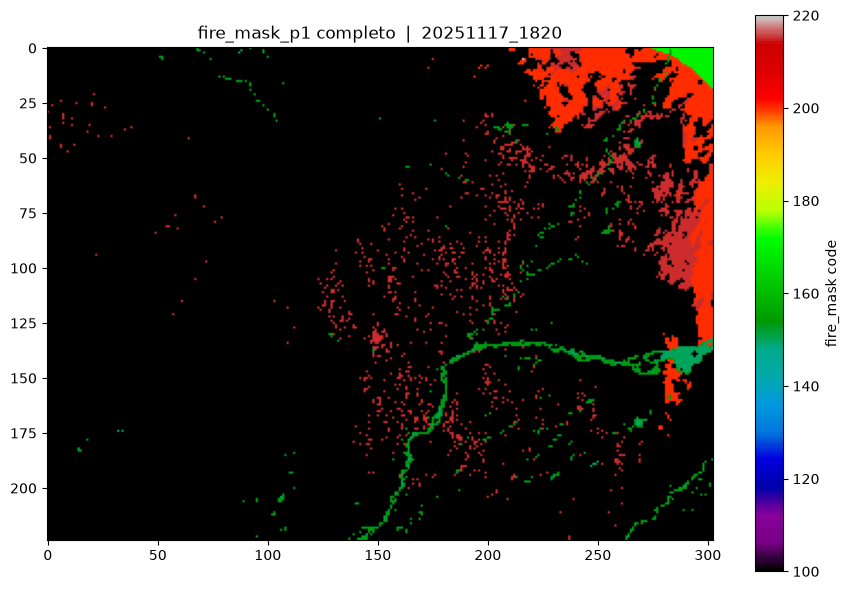


Nota: los píxeles candidatos (que pasan a Part II) tienen fire_mask == FireMask.FIRE_FREE
  FireMask.FIRE_FREE = 100


In [115]:
# Visualización de la fire_mask de Part I
fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(fire_mask_p1, cmap='nipy_spectral', origin='upper',
               vmin=fire_mask_p1.min(), vmax=fire_mask_p1.max())
plt.colorbar(im, ax=ax, label='fire_mask code')
ax.set_title(f'fire_mask_p1 completo  |  {TIMESTAMP}')
plt.tight_layout()
plt.show()

print('\nNota: los píxeles candidatos (que pasan a Part II) tienen fire_mask == FireMask.FIRE_FREE')
print(f'  FireMask.FIRE_FREE = {FireMask.FIRE_FREE}')

## Chequeo cruzado: df_final (notebook) vs candidates (producción)

In [116]:
cand_map  = {(c.i, c.j): c for c in candidates}
final_map = {(int(r.i), int(r.j)): r for r in df_final.itertuples()}

only_manual = set(final_map) - set(cand_map)
only_prod   = set(cand_map) - set(final_map)
both        = set(final_map) & set(cand_map)

print(f"Solo en df_final (manual):  {len(only_manual)}")
print(f"Solo en candidates (prod):  {len(only_prod)}")
print(f"En ambos:                   {len(both)}")

rows = []
for (i, j) in both:
    m, p = final_map[(i, j)], cand_map[(i, j)]
    rows.append({
        'i': i, 'j': j,
        'frp_manual': m.frp, 'frp_prod': p.frp,
        'd_frp': abs(m.frp - p.frp) if np.isfinite(m.frp) and np.isfinite(p.frp) else np.nan,
        'fire_temp_manual': m.fire_temp, 'fire_temp_prod': p.fire_temp,
        'fail_char_manual': m.fail_char, 'fail_char_prod': p.fail_char,
    })
df_cross = pd.DataFrame(rows)
print(f"\nDiferencia de FRP > 0.01 MW en: {(df_cross.d_frp > 0.01).sum()} de {len(df_cross)}")
display(df_cross.sort_values('d_frp', ascending=False).head(15))

Solo en df_final (manual):  2
Solo en candidates (prod):  7
En ambos:                   206

Diferencia de FRP > 0.01 MW en: 0 de 206


,i,j,frp_manual,frp_prod,d_frp,fire_temp_manual,fire_temp_prod,fail_char_manual,fail_char_prod
0,87,7,0.000026,0.000026,0.0,-999.000000,-999.000000,4,4
141,99,9,0.000062,0.000062,0.0,-999.000000,-395.988475,8,9
131,54,75,0.000039,0.000039,0.0,-999.000000,-999.000000,-1,6
132,12,124,0.000028,0.000028,0.0,-999.000000,-360.305034,-1,9
133,7,18,0.000040,0.000040,0.0,-999.000000,-999.000000,-1,9
134,169,98,0.000040,0.000040,0.0,404.293438,404.293438,-1,-1
135,60,72,0.000060,0.000060,0.0,-999.000000,-999.000000,-1,9
136,170,97,0.000045,0.000045,0.0,-999.000000,-357.597600,-1,9
137,79,52,0.000039,0.000039,0.0,-999.000000,-355.587132,-1,6
138,84,222,0.000053,0.000053,0.0,403.340485,403.340485,-1,-1


### CODIGOS 150-153
Chequeamos que siempre correspondan a los mismos pixeles

In [117]:
from pathlib import Path
import numpy as np
import pandas as pd

MASK_DIR = Path(
    "/Users/valentinachagas/Documents/GitHub/GERIS-PFC/"
    "obtencion_imagenes/dataset/uruguay/ABI-L2-FDCF-Mask"
)

CODES = {
    150: "BAD_ECOSYSTEM",
    151: "SEAWATER",
    152: "COASTFRINGE",
    153: "INLAND_WATER",
}

RNG_SEED = 42
N_SAMPLE = 40

files = sorted(
    path for path in MASK_DIR.glob("*.npy")
    if "20251115_0000" <= path.stem <= "20251215_2359"
)

if len(files) < N_SAMPLE:
    raise RuntimeError(
        f"Solo hay {len(files)} máscaras en el período; "
        f"no se pueden tomar {N_SAMPLE}."
    )

rng = np.random.default_rng(RNG_SEED)
sample = sorted(rng.choice(files, size=N_SAMPLE, replace=False))

masks = np.stack(
    [np.load(path).astype(np.int8) for path in sample],
    axis=0,
)

rows = []

for code, name in CODES.items():
    locations = masks == code
    reference = locations[0]

    identical = np.all(
        locations == reference,
        axis=(1, 2),
    )

    counts = locations.sum(axis=(1, 2))
    same_everywhere = bool(identical.all())

    rows.append({
        "Código": code,
        "Nombre": name,
        "¿Mismos píxeles en las 10?": "✅ Sí" if same_everywhere else "❌ No",
        "Píxeles mín.": int(counts.min()),
        "Píxeles máx.": int(counts.max()),
        "Escenas idénticas": f"{identical.sum()}/{N_SAMPLE}",
    })

result = pd.DataFrame(rows)

print("Muestra aleatoria:")
for path in sample:
    print("•", path.stem)

display(result)

Muestra aleatoria:
• 20251116_2320
• 20251117_1520
• 20251117_1740
• 20251117_2020
• 20251117_2130
• 20251118_2250
• 20251120_1510
• 20251121_0450
• 20251122_0040
• 20251123_1350
• 20251126_1040
• 20251127_1030
• 20251128_0730
• 20251128_1150
• 20251128_1700
• 20251128_2130
• 20251128_2220
• 20251130_1040
• 20251130_1950
• 20251201_0500
• 20251201_2040
• 20251202_0400
• 20251204_1350
• 20251204_2130
• 20251205_0250
• 20251206_1100
• 20251207_0240
• 20251207_1600
• 20251208_1050
• 20251208_1850
• 20251209_0330
• 20251209_0540
• 20251210_1020
• 20251210_1520
• 20251210_2150
• 20251211_0950
• 20251211_1400
• 20251212_1150
• 20251213_1500
• 20251215_0110


,Código,Nombre,¿Mismos píxeles en las 10?,Píxeles mín.,Píxeles máx.,Escenas idénticas
0,150,BAD_ECOSYSTEM,✅ Sí,0,0,40/40
1,151,SEAWATER,✅ Sí,0,0,40/40
2,152,COASTFRINGE,✅ Sí,0,0,40/40
3,153,INLAND_WATER,✅ Sí,0,0,40/40


Podemos asumir que siempre son los mismos pixeles y hacer un parche por ahora. Es lo que implementamos en la parte 3.

### Estadisticas de la parte 1

Fire mask codes 10, 12, 15, 30, 32, 33 y 35 son parte de la clasificación final. No corresponden a la parte 1.

PROCESSED=10, SATURATED=11, CLOUD_CONTAM=12, HIGH_PROB=13, MED_PROB=14, LOW_PROB=15,
TEMP_PROCESSED=30, TEMP_SATURATED=31, TEMP_CLOUD=32, TEMP_HIGH=33, TEMP_MED=34, TEMP_LOW=35

In [122]:
print("n_candidates:", result["n_candidates"])
print("fuegos_noaa:", result["fuegos_noaa"])

n_candidates: 213
fuegos_noaa: 7


In [123]:
noaa_rows, noaa_cols = np.where(noaa_fire)
cand_rows = np.array([c.i for c in candidates])
cand_cols = np.array([c.j for c in candidates])

print("rango filas NOAA fuego:", noaa_rows.min() if len(noaa_rows) else None, noaa_rows.max() if len(noaa_rows) else None)
print("rango cols NOAA fuego:", noaa_cols.min() if len(noaa_cols) else None, noaa_cols.max() if len(noaa_cols) else None)
print("rango filas candidatos:", cand_rows.min() if len(cand_rows) else None, cand_rows.max() if len(cand_rows) else None)
print("rango cols candidatos:", cand_cols.min() if len(cand_cols) else None, cand_cols.max() if len(cand_cols) else None)

# ¿Hay overlap aunque sea aproximado (radio de 2px)?
from scipy.spatial import cKDTree
if len(noaa_rows) and len(cand_rows):
    tree = cKDTree(np.column_stack([cand_rows, cand_cols]))
    dist, _ = tree.query(np.column_stack([noaa_rows, noaa_cols]))
    print("distancia media al candidato más cercano:", dist.mean())
    print("% de fuegos NOAA con un candidato a <=2px:", (dist <= 2).mean())

rango filas NOAA fuego: 39 114
rango cols NOAA fuego: 27 158
rango filas candidatos: 1 222
rango cols candidatos: 0 289
distancia media al candidato más cercano: 13.687149995542997
% de fuegos NOAA con un candidato a <=2px: 0.0


In [124]:
noaa_rows, noaa_cols = np.where(noaa_fire)
print("Código Part I en los 7 píxeles fuego NOAA:")
print(fire_mask_p1[noaa_rows, noaa_cols])
print("fail_char en esos mismos píxeles:")
print(fail_char_p1[noaa_rows, noaa_cols])

Código Part I en los 7 píxeles fuego NOAA:
[100 215 100 100 100 100 100]
fail_char en esos mismos píxeles:
[2 2 2 2 2 2 2]


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd

from fdca.constants import FireMask
from fdca.part1 import run_part1
from fdca.fdca_adapter import load_fdca_input, build_tpw_lut


IMPLEMENTATION_ROOT = Path(
    "/Users/valentinachagas/Documents/GitHub/GERIS-PFC/implementacion"
)

DATASET_ROOT = Path(
    "/Users/valentinachagas/Documents/GitHub/GERIS-PFC/"
    "obtencion_imagenes/dataset"
)

CONFIG_PATH = IMPLEMENTATION_ROOT / "fdca" / "config.yaml"

MASK_DIR = Path(
    "/Users/valentinachagas/Documents/GitHub/GERIS-PFC/"
    "obtencion_imagenes/dataset/uruguay/ABI-L2-FDCF-Mask"
)

REGION = "uruguay"

RNG_SEED = 42
N_SAMPLE = 1

PART2_CODES = {
    10, 11, 12, 13, 14, 15,
    30, 31, 32, 33, 34, 35
}


FIRE_CODES = {
    # Detecciones de la Fase I (sin filtro temporal)
    FireMask.PROCESSED,      # 10
    FireMask.SATURATED,      # 11
    FireMask.CLOUD_CONTAM,   # 12
    FireMask.HIGH_PROB,      # 13
    FireMask.MED_PROB,       # 14
    FireMask.LOW_PROB,       # 15

    # Detecciones de la Fase II (con filtro temporal)
    FireMask.TEMP_PROCESSED, # 30
    FireMask.TEMP_SATURATED, # 31
    FireMask.TEMP_CLOUD,     # 32
    FireMask.TEMP_HIGH,      # 33
    FireMask.TEMP_MED,       # 34
    FireMask.TEMP_LOW        # 35
}


def evaluate_scene(path, lut_tpw):

    ts = path.stem

    ref_mask = np.load(path).astype(np.uint8)

    try:
        inp = load_fdca_input(
            timestamp=ts,
            region=REGION,
            dataset_root=str(DATASET_ROOT),
            config_path=str(CONFIG_PATH),
            verbose=False,
        )
    except FileNotFoundError as e:
        print(f"⚠ {ts}: input faltante")
        return None

    FPT = getattr(inp, "FPT", 0.0) or 0.0

    fire_mask_p1, fail_char_p1, candidates = run_part1(
        bt7=inp.bt7,
        rad7=inp.rad7,
        bt14=inp.bt14,
        rad14=inp.rad14,
        bt13=inp.bt13,
        rad13=inp.rad13,
        bt15=inp.bt15,
        refl2=inp.refl2,

        latitudes=inp.latitudes,
        longitudes=inp.longitudes,

        sza=inp.sza,
        glint_angle=inp.glint_angle,
        lza=inp.lza,
        azimuth=inp.azimuth,

        tpw=inp.tpw,

        emiss7=inp.emiss7,
        emiss14=inp.emiss14,

        lut_tpw=lut_tpw,
        FPT=FPT,

        coeffs7=inp.coeffs7,
        coeffs14=inp.coeffs14,
        coeffs13=inp.coeffs13,

        land_mask=inp.land_mask,
        eco_mask=eco_mask,

        data_quality=getattr(inp, "data_quality", None),
    )

    if fire_mask_p1.shape != ref_mask.shape:
        print(f"⚠ {ts}: shapes incompatibles")
        return None

    # ========================================================
    # 1. AGREEMENT PART I vs NOAA
    # ========================================================

    valid = ~np.isin(ref_mask, list(PART2_CODES))

    n_valid = int(valid.sum())

    n_match = int(
        np.sum(
            fire_mask_p1[valid] == ref_mask[valid]
        )
    )

    accuracy = (
        n_match / n_valid
        if n_valid > 0
        else np.nan
    )

    # ========================================================
    # 2. CANDIDATOS vs FUEGOS NOAA (desglosado por categoría)
    # ========================================================

    candidate_mask = np.zeros_like(
        ref_mask,
        dtype=bool
    )

    for candidate in candidates:
        candidate_mask[
            candidate.i,
            candidate.j
        ] = True

    noaa_fire = np.isin(
        ref_mask,
        list(FIRE_CODES)
    )

    n_noaa_fire = int(noaa_fire.sum())

    n_fire_in_candidates = int(
        np.sum(
            noaa_fire & candidate_mask
        )
    )

    candidate_recall = (
        n_fire_in_candidates / n_noaa_fire
        if n_noaa_fire > 0
        else np.nan
    )

    # Desglose por categoría NOAA
    CATEGORY_NAMES = {
        10: "PROCESSED", 11: "SATURATED", 12: "CLOUD_CONTAM",
        13: "HIGH_PROB", 14: "MED_PROB", 15: "LOW_PROB",
        30: "TEMP_PROCESSED", 31: "TEMP_SATURATED", 32: "TEMP_CLOUD",
        33: "TEMP_HIGH", 34: "TEMP_MED", 35: "TEMP_LOW",
    }

    category_breakdown = {}
    for code in sorted(FIRE_CODES):
        code_mask = (ref_mask == code)
        n_total = int(code_mask.sum())
        if n_total == 0:
            continue
        n_detected = int((code_mask & candidate_mask).sum())
        category_breakdown[CATEGORY_NAMES.get(code, str(code))] = {
            "n_noaa": n_total,
            "n_detected": n_detected,
            "recall": n_detected / n_total,
        }

    # FN analysis: what Part I code did the missed fires get?
    fn_mask = noaa_fire & ~candidate_mask
    fn_codes = {}
    if fn_mask.any():
        fn_part1_codes = fire_mask_p1[fn_mask]
        from fdca.constants import FireMask as FM
        fm_names = {v: k for k, v in vars(FM).items() if not k.startswith("_") and isinstance(v, int)}
        for code in np.unique(fn_part1_codes):
            fn_codes[fm_names.get(int(code), str(code))] = int((fn_part1_codes == code).sum())

    # ========================================================
    # 3. Cantidad de candidatos
    # ========================================================

    n_candidates = len(candidates)

    return {
        "timestamp": ts,

        "pixeles_comparables": n_valid,
        "pixeles_coincidentes": n_match,
        "accuracy_part1": accuracy,

        "fuegos_noaa": n_noaa_fire,
        "fuegos_noaa_en_candidates": n_fire_in_candidates,
        "candidate_recall": candidate_recall,

        "n_candidates": n_candidates,
        "category_breakdown": category_breakdown,
        "fn_part1_codes": fn_codes,
    }


# ============================================================
# SELECCIONAR 20 TIMESTAMPS
# ============================================================

files = sorted(
    p for p in MASK_DIR.glob("*.npy")
    if "20251115_0000" <= p.stem <= "20251215_2359"
)

rng = np.random.default_rng(RNG_SEED)

sample = sorted(
    rng.choice(
        files,
        size=min(N_SAMPLE, len(files)),
        replace=False
    )
)

print("Timestamps seleccionados:")
for p in sample:
    print(" •", p.stem)


# ============================================================
# EJECUTAR
# ============================================================

lut_tpw = build_tpw_lut()

results = []

for path in sample:

    print(f"\nProcesando {path.stem}...")

    result = evaluate_scene(
        path,
        lut_tpw
    )

    if result is not None:
        results.append(result)

        print(
            f"  Accuracy Part I: "
            f"{result['accuracy_part1']:.2%}"
        )

        print(
            f"  NOAA fires: "
            f"{result['fuegos_noaa']}"
        )

        print(
            f"  NOAA fires en candidates: "
            f"{result['fuegos_noaa_en_candidates']}"
        )

        print(
            f"  Candidate recall: "
            f"{result['candidate_recall']:.2%}"
        )

        print(
            f"  Candidates totales: "
            f"{result['n_candidates']}"
        )


# ============================================================
# TABLA FINAL
# ============================================================

df = pd.DataFrame(results)

print("\n")
print("=" * 80)
print("RESULTADOS")
print("=" * 80)

print(
    df[
        [
            "timestamp",
            "accuracy_part1",
            "fuegos_noaa",
            "fuegos_noaa_en_candidates",
            "candidate_recall",
            "n_candidates",
        ]
    ].to_string(index=False)
)

print("\nPromedios:")
print(
    f"Accuracy Part I:   "
    f"{df['accuracy_part1'].mean():.2%}"
)

print(
    f"Candidate recall:   "
    f"{df['candidate_recall'].mean():.2%}"
)

# ============================================================
# DESGLOSE POR CATEGORÍA DE FUEGO NOAA
# ============================================================

print("\n")
print("=" * 80)
print("DESGLOSE POR CATEGORÍA DE FUEGO NOAA")
print("=" * 80)

cat_rows = []
for result in results:
    for cat_name, cat_data in result.get("category_breakdown", {}).items():
        cat_rows.append({
            "timestamp": result["timestamp"],
            "category": cat_name,
            "n_noaa": cat_data["n_noaa"],
            "n_detected": cat_data["n_detected"],
            "recall": cat_data["recall"],
        })

if cat_rows:
    df_cat = pd.DataFrame(cat_rows)
    agg = df_cat.groupby("category").agg(
        total_noaa=("n_noaa", "sum"),
        total_detected=("n_detected", "sum"),
    ).reset_index()
    agg["recall"] = agg["total_detected"] / agg["total_noaa"]
    agg = agg.sort_values("total_noaa", ascending=False)
    print(agg.to_string(index=False))
else:
    print("No hay fuegos NOAA en la muestra.")

# ============================================================
# DIAGNÓSTICO FN: ¿Qué código Part I les asignó?
# ============================================================

print("\n")
print("=" * 80)
print("FALSOS NEGATIVOS: código Part I asignado")
print("=" * 80)

fn_rows = []
for result in results:
    for code_name, count in result.get("fn_part1_codes", {}).items():
        fn_rows.append({"code": code_name, "count": count})

if fn_rows:
    df_fn = pd.DataFrame(fn_rows).groupby("code")["count"].sum().sort_values(ascending=False).reset_index()
    print(df_fn.to_string(index=False))
    print("\n→ FIRE_FREE = pasó filtros pero no fue anómalo vs background (fuego débil)")
    print("→ CLOUD_* = fue clasificado como nube")
    print("→ Otros = descartado por ángulo, agua, ecosistema, etc.")
else:
    print("No hay falsos negativos — todos los fuegos NOAA son candidatos.")

Timestamps seleccionados:
 • 20251117_1820

Procesando 20251117_1820...


KeyboardInterrupt: 

---
## ¿Qué sigue?

La lista `candidates` y los arrays `fire_mask_p1`, `fail_char_p1` son la entrada de **Part II** (`run_part2`), que aplica:
- tests de confirmación / eliminación de falsas alarmas (`cond1`, `cond2`, `cond3`)
- upgrade de confianza (→ HIGH/MED/LOW)
- filtrado temporal (offset +20)

El notebook de Part II seguirá la misma estructura modular.